<a href="https://colab.research.google.com/github/janhavishukla10/Aerofit-customer-segmentation/blob/main/Yulu_Hypothesis_Testing_Business_Case_Study_Janhavi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **YULU BIKE CASE STUDY**

**About Yulu:**

Yulu is India’s leading micro-mobility service provider, which offers unique vehicles for the daily commute. Starting off as a mission to eliminate traffic congestion in India, Yulu provides the safest commute solution through a user-friendly mobile app to enable shared, solo and sustainable commuting.

Yulu zones are located at all the appropriate locations (including metro stations, bus stands, office spaces, residential areas, corporate offices, etc) to make those first and last miles smooth, affordable, and convenient!

**Business Problem**

Yulu has recently suffered considerable dips in its revenues. They have contracted a consulting company to understand the factors on which the demand for these shared electric cycles depends. Specifically, they want to understand the factors affecting the demand for these shared electric cycles in the Indian market.


**The company wants to know:**

1.   Which variables are significant in predicting the demand for shared electric cycles in the Indian market?

2.   How well those variables describe the electric cycle demands?

# **Dataset:**

**The company collected the data of customers who used their services.**

Dataset Link: yulu_data.csv

**Column Profiling:**

**datetime:** datetime

**season:** season (1: spring, 2: summer, 3: fall, 4: winter)

**holiday:** whether day is a holiday or not

**workingday:** if day is neither weekend nor holiday is 1, otherwise is 0.

**weather:**

1: Clear, Few clouds, partly cloudy, partly cloudy

2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist

3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds

4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog

**temp:** temperature in Celsius

**atemp:** feeling temperature in Celsius

**humidity:** humidity

**windspeed:** wind speed

**casual:** count of casual users

**registered:** count of registered users

**count:** count of total rental bikes including both casual and registered


# **1. Define Problem Statement and perform Exploratory Data Analysis (EDA):**

**1A. Define Problem Statement:**

1.   Which variables are significant in predicting the demand for shared electric cycles in the Indian market?
2.   How well those variables describe the electric cycle demands?
3. Analyzing Factors Affecting Demand for Yulu's Shared Electric Cycles in India.



**1B. Perform Exploratory Data Analysis (EDA):**


1. Importing the libraries.
2. Reading the dataset.
3. Looking at the dataset.
4. Observations on shape of data and examining structure of dataset.
5. Basic information about the dataset and checking data types of all the attributes.
6. Statistical summary.
7. Conversion of categorical attributes to 'category' (If required).
8. Find what is the time period for which the data is given.
9. Missing value detection and perform Imputation using an appropriate method.
10. Identify and remove duplicate records.
11. Univariate Analysis (Distribution plots of all the continuous variable(s) barplots/countplots of all the categorical variables). Comment on these univariate plots.
12. Bivariate Analysis (Relationships between important variables such as workday and count, season and count, weather and count). Comment on these bivariate plots.
13. Check for Outliers and deal with them accordingly.
14. Establish a Relationship between Dependent and Independent Variables.


**Importing Libraries:**



In [2]:
import numpy as np   # linear algebra

import pandas as pd   # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt  # data visualization

import seaborn as sns  # data visualization

import datetime as dt  # working with dates and times

import scipy.stats as spy  # statistical analysis

import statsmodels.api as sm  # statistical analysis

from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu  # perform hypothesis testing

import warnings  # control how warnings are handled
warnings.filterwarnings('ignore')

**Reading the Dataset**

In [3]:
url = "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/428/original/bike_sharing.csv?1642089089"

df = pd.read_csv(url)

In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
df.shape

(10886, 12)

In [5]:
print(f"# rows: {df.shape[0]} \n# columns: {df.shape[1]}")

# rows: 10886 
# columns: 12


In [6]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

**Basic info about data**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


**Observation-**

1.   These statistics provide insights into the central tendency, spread, and range of the numerical features in the dataset.
2.   The difference between mean and median is much heigher in count columns hence finding out the outlier by using IQR technique and removing it would be good.

Datatype of following attributes needs to changed to proper data type:
* datetime - to datetime
* season - to categorical
* holiday - to categorical
* workingday - to categorical
* weather - to categorical

In [7]:
df['datetime'] = pd.to_datetime(df['datetime'])

cat_cols= ['season', 'holiday', 'workingday', 'weather']
for col in cat_cols:
    df[col] = df[col].astype('object')

In [8]:
df.describe()

,datetime,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399411968,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
min,2011-01-01 00:00:00,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-02 07:15:00,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,2012-01-01 20:30:00,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,2012-07-01 12:45:00,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,2012-12-19 23:00:00,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000
std,NaN,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454


**Observation-**

* There are no missing values in the dataset.
* **casual** and **registered** attributes might have outliers because their mean and median are very far away to one another and the value of standard deviation is also high which tells us that there is high variance in the data of these attributes.

In [9]:
df.describe(include = 'object')

,season,holiday,workingday,weather
count,10886,10886,10886,10886
unique,4,2,2,4
top,4,0,1,1
freq,2734,10575,7412,7192


In [10]:
df.describe(include = 'datetime')

,datetime
count,10886
mean,2011-12-27 05:56:22.399411968
min,2011-01-01 00:00:00
25%,2011-07-02 07:15:00
50%,2012-01-01 20:30:00
75%,2012-07-01 12:45:00
max,2012-12-19 23:00:00


**Find what is the time period for which the data is given:**

In [11]:
df['datetime'].min()

Timestamp('2011-01-01 00:00:00')

In [12]:
df['datetime'].max()

Timestamp('2012-12-19 23:00:00')

In [13]:
df['datetime'].max() - df['datetime'].min()

Timedelta('718 days 23:00:00')

**Observation-**

The data is given from Timestamp('2011-01-01 00:00:00') to Timestamp('2012-12-19 23:00:00'). The total time period for which the data is given is '718 days 23:00:00'.

**Missing value detection and perform imputation:**


In [14]:
df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


**Observation-**

There are no missing values in the dataset.

**Identify and remove duplicate records:**

In [17]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
10881,False
10882,False
10883,False
10884,False


In [23]:
np.any(df.duplicated())

np.False_

Observation-
There are no duplicate values in the dataset.

Univariate Analysis (Pie charts of all the categorical variables):

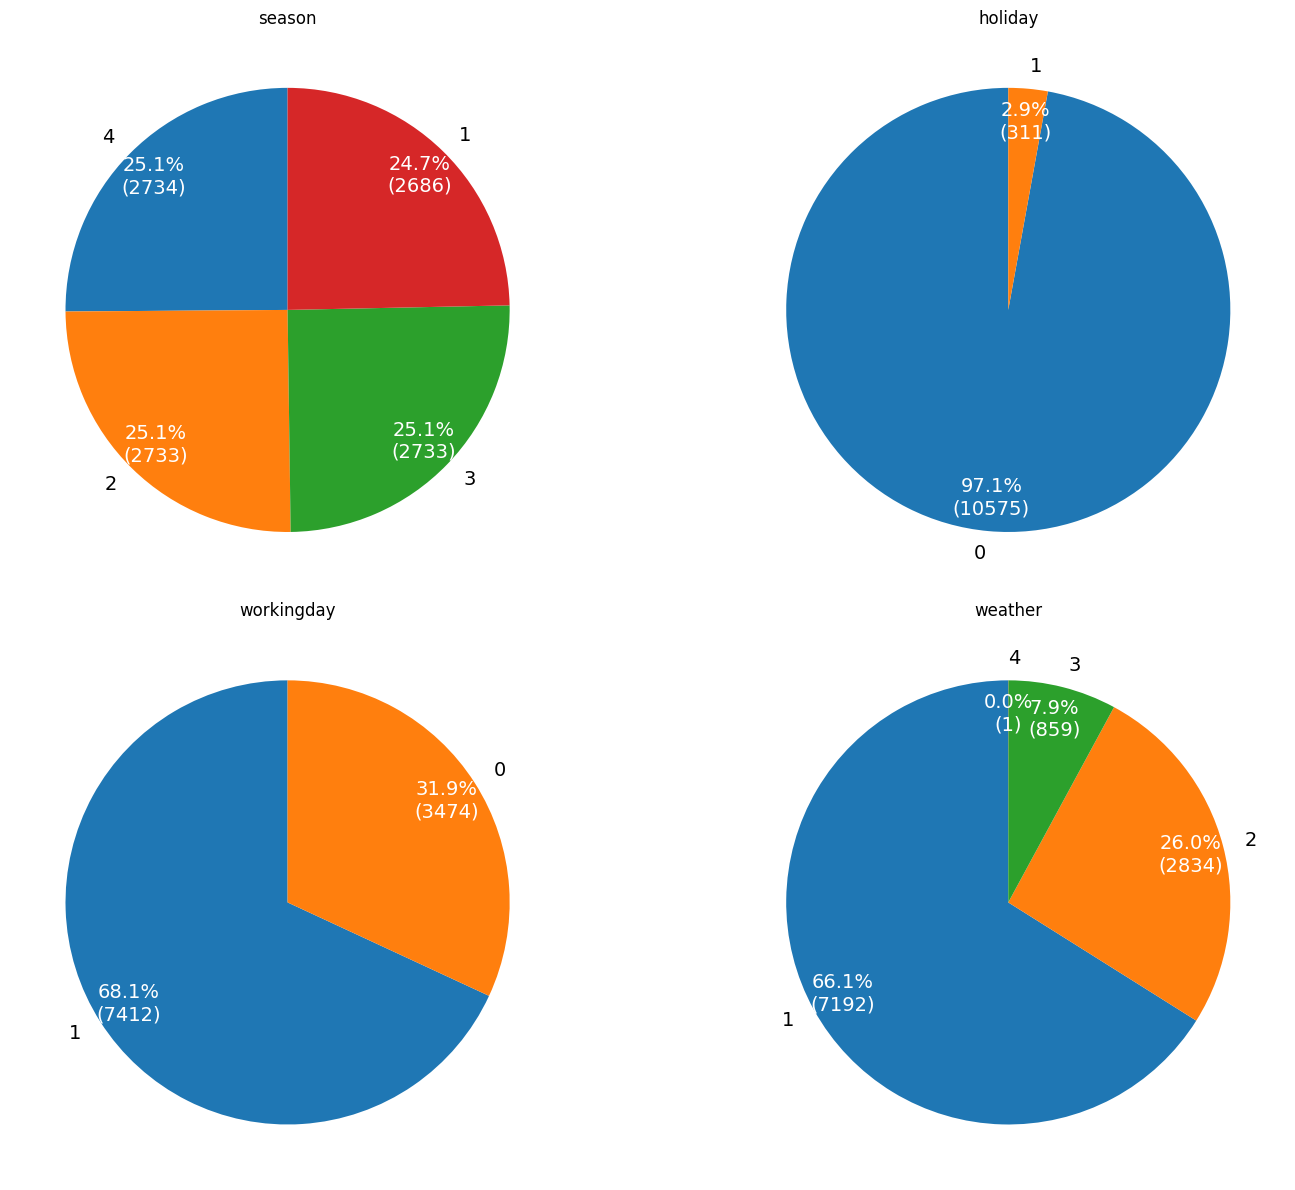

In [24]:
# Define the categorical columns
cat_cols = ['season', 'holiday', 'workingday', 'weather']

fig, axis = plt.subplots(nrows = 2,  # Create a 2x2 grid for subplots
                         ncols = 2,
                         figsize = (16, 12))

index = 0

def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val})'
    return my_format

for row in range(2):
    for col in range(2):
        counts = df[cat_cols[index]].value_counts()  # Count the occurrences of each category

        # Create a pie chart with customized percentage formatting
        wedges, texts, autotexts = axis[row, col].pie(
            counts,
            labels = counts.index,
            autopct = autopct_format(counts),
            startangle = 90,
            textprops = {'fontsize': 14},
            pctdistance = 0.85
        )

        for autotext in autotexts:  # Increase the font size of the percentage labels
            autotext.set_fontsize(14)
            autotext.set_color('white')

        axis[row, col].set_title(cat_cols[index])

        index += 1

plt.tight_layout()
plt.show()  # Displaying the plots

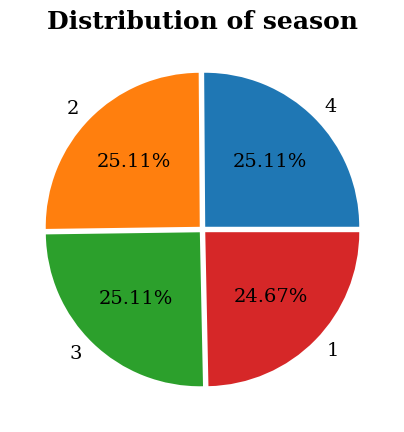

In [27]:
plt.figure(figsize = (5, 5))  # Setting the figure size to 5x5

# Setting the title of the plot
plt.title('Distribution of season', fontdict = {'fontsize' : 18,
                                                'fontweight' : 600,
                                                'fontstyle' : 'normal',
                                                'fontfamily' : 'serif'})

df_season = np.round(df['season'].value_counts(normalize = True) * 100, 2).to_frame()

plt.pie(x = df_season['proportion'],  # Plotting the pie-chart
        explode = [0.025, 0.025, 0.025, 0.025],
        labels = df_season.index,
        autopct = '%.2f%%',
        textprops = {'fontsize' : 14,
                     'fontstyle' : 'normal',
                     'fontfamily' : 'serif',
                     'fontweight' : 500})

plt.show()  # Displaying the plot

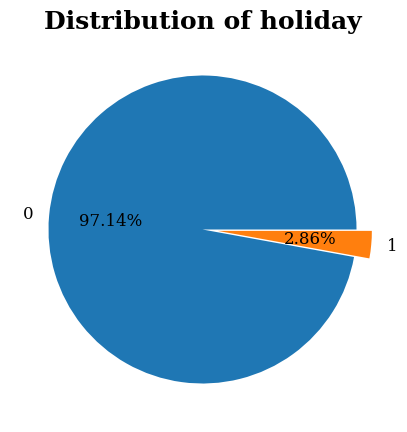

In [29]:
plt.figure(figsize = (5, 5))  # Setting the figure size to 5x5

# Setting the title of the plot
plt.title('Distribution of holiday', fontdict = {'fontsize' : 18,
                                                'fontweight' : 600,
                                                'fontstyle' : 'normal',
                                                'fontfamily' : 'serif'})

df_holiday = np.round(df['holiday'].value_counts(normalize = True) * 100, 2).to_frame()

plt.pie(x = df_holiday['proportion'],  # Plotting the pie-chart
        explode = [0, 0.1],
        labels = df_holiday.index,
        autopct = '%.2f%%',
        textprops = {'fontsize' : 12,
                     'fontstyle' : 'normal',
                     'fontfamily' : 'serif',
                     'fontweight' : 500})

plt.show()  # Displaying the plot

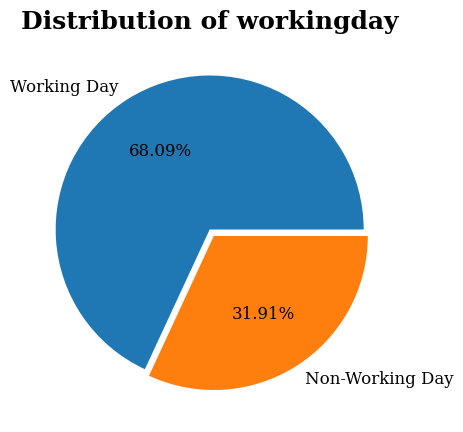

In [31]:
plt.figure(figsize = (5, 5))  # Setting the figure size to 5x5

# Setting the title of the plot
plt.title('Distribution of workingday', fontdict = {'fontsize' : 18,
                                                'fontweight' : 600,
                                                'fontstyle' : 'normal',
                                                'fontfamily' : 'serif'})

df_workingday = np.round(df['workingday'].value_counts(normalize = True) * 100, 2).to_frame()

plt.pie(x = df_workingday['proportion'],  # Plotting the pie-chart
        explode = [0, 0.05],
        labels = ['Working Day', 'Non-Working Day'],
        autopct = '%.2f%%',
        textprops = {'fontsize' : 12,
                     'fontstyle' : 'normal',
                     'fontfamily' : 'serif',
                     'fontweight' : 500})

plt.show()  # Displaying the plot

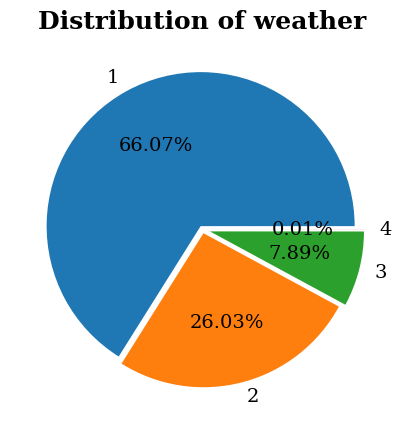

In [32]:
plt.figure(figsize = (5, 5))  # Setting the figure size to 5x5

# Setting the title of the plot
plt.title('Distribution of weather', fontdict = {'fontsize' : 18,
                                                'fontweight' : 600,
                                                'fontstyle' : 'normal',
                                                'fontfamily' : 'serif'})

df_weather = np.round(df['weather'].value_counts(normalize = True) * 100, 2).to_frame()

plt.pie(x = df_weather['proportion'],  # Plotting the pie-chart
        explode = [0.025, 0.025, 0.05, 0.05],
        labels = df_weather.index,
        autopct = '%.2f%%',
        textprops = {'fontsize' : 14,
                   'fontstyle' : 'normal',
                   'fontfamily' : 'serif',
                   'fontweight' : 500})

plt.show()  # Displaying the plot

In [33]:
distribution_of_season = df['season'].value_counts()
distribution_of_holiday = df['holiday'].value_counts()
distribution_of_workingday = df['workingday'].value_counts()
distribution_of_weather = df['weather'].value_counts()

print("Distribution of Season:")
print(distribution_of_season)
print("\nDistribution of Holiday:")
print(distribution_of_holiday)
print("\nDistribution of Working day:")
print(distribution_of_workingday)
print("\nDistribution of Weather:")
print(distribution_of_weather)

Distribution of Season:
season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64

Distribution of Holiday:
holiday
0    10575
1      311
Name: count, dtype: int64

Distribution of Working day:
workingday
1    7412
0    3474
Name: count, dtype: int64

Distribution of Weather:
weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64


Observation-
1. In each season count of renting cycles is almost same at around 25%.
2. Renting of yulu electric bikes on a holiday is extremely less at 2.9% than other days at 97.1%.
3. Usage of yulu electric bikes on working day 68.1% is more than holidays including weekends 31.9%.
4. Weather 1 & 2 has maximum usage of yulu electric bikes at 92.1% as compared to weather 3 & 4 at 7.9%. Details of weather 1, 2, 3 and 4 are mentioned in column profiling of the dataset.


**Bivariate Analysis (Relationships between important variables):**

Plotting categorical variables vs count using boxplots-

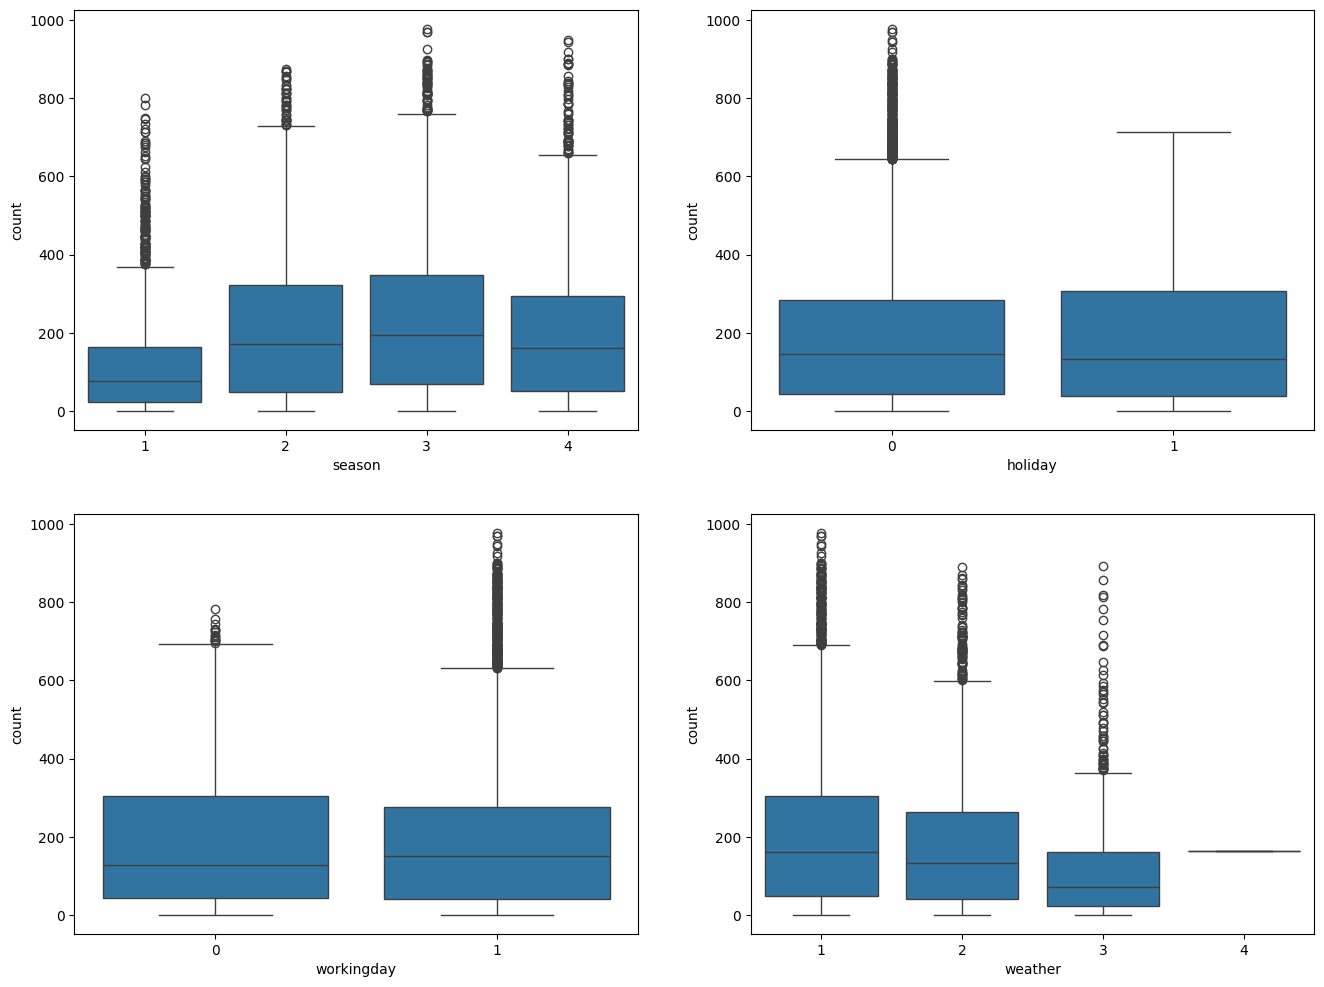

In [34]:
# Define the categorical columns
cat_cols = ['season', 'holiday', 'workingday', 'weather']

fig, axis = plt.subplots(nrows = 2,  # Setting the figure size to 2x2
                         ncols = 2,
                         figsize = (16, 12))

index = 0

for row in range(2):  # Plotting boxplots
    for col in range(2):
        sns.boxplot(data = df,
                    x = cat_cols[index],
                    y = 'count',
                    ax = axis[row, col])
        index += 1


plt.show()  # Displaying the plots

Plotting categorical variables vs count using KDE plots-

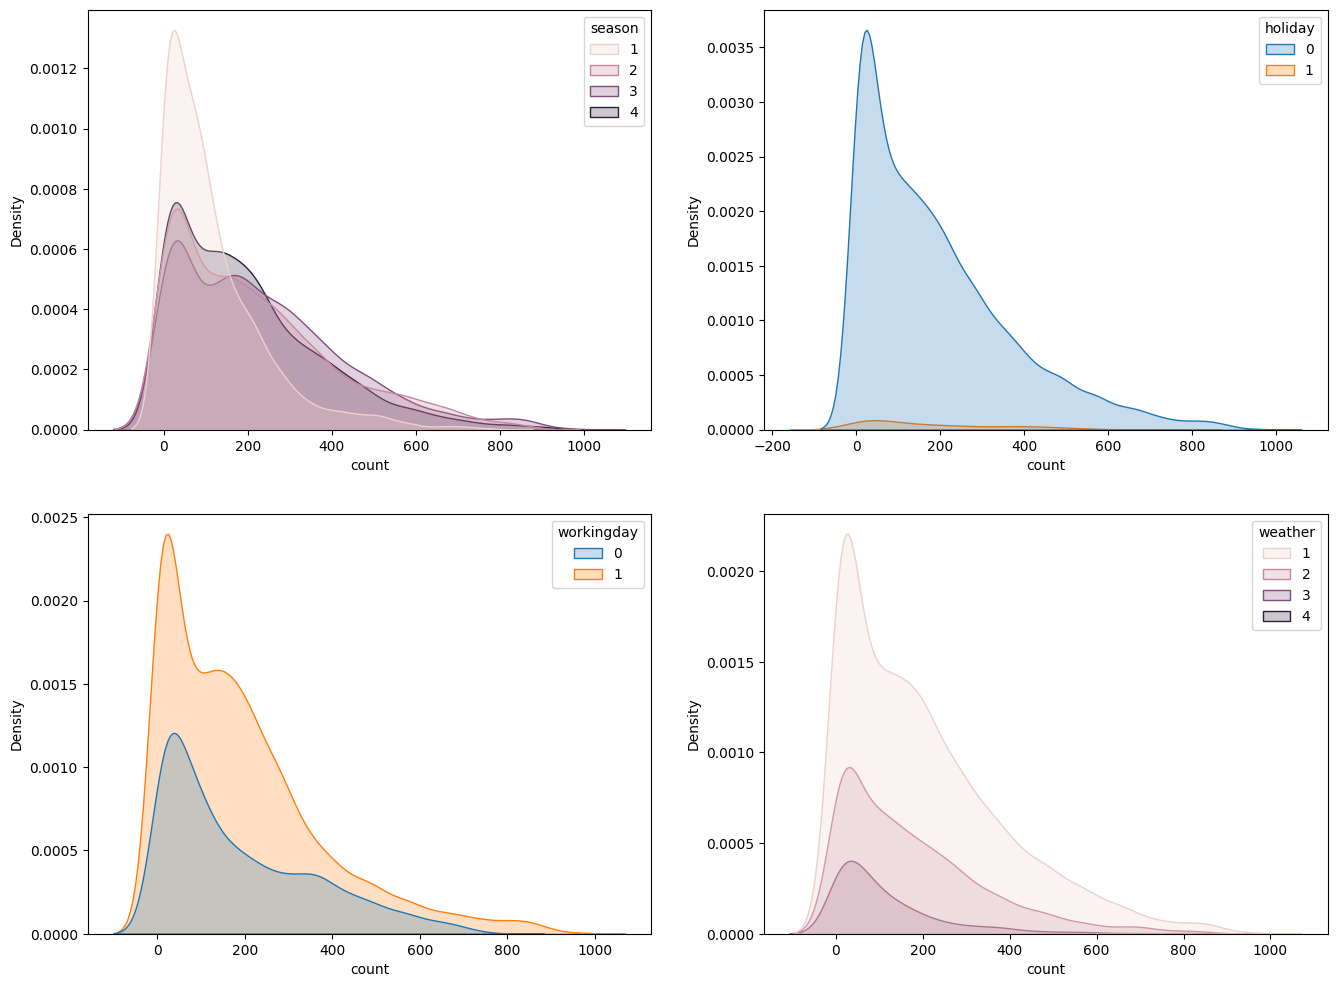

In [35]:
# Define the categorical columns
cat_cols = ['season', 'holiday', 'workingday', 'weather']

fig, axis = plt.subplots(nrows = 2,  # Setting the figure size to 2x2
                         ncols = 2,
                         figsize = (16, 12))

index = 0

for row in range(2):  # Plotting KDE plots
    for col in range(2):
        sns.kdeplot(x = 'count',
            data = df,
            hue = cat_cols[index],
            color = 'green',
            shade = True,
            ax = axis[row, col])

        index += 1

plt.show() # Displaying the plots

Observations :-
1. In summer and fall seasons more bikes are rented as compared to other seasons.
2. Whenever its a holiday more bikes are rented.
3. It is also clear from the workingday also that whenever day is holiday or weekend, slightly more bikes were rented.
4. Whenever there is rain, thunderstorm, snow or fog, there were less bikes were rented.

**Plotting numerical variables vs count using scatterplot-**

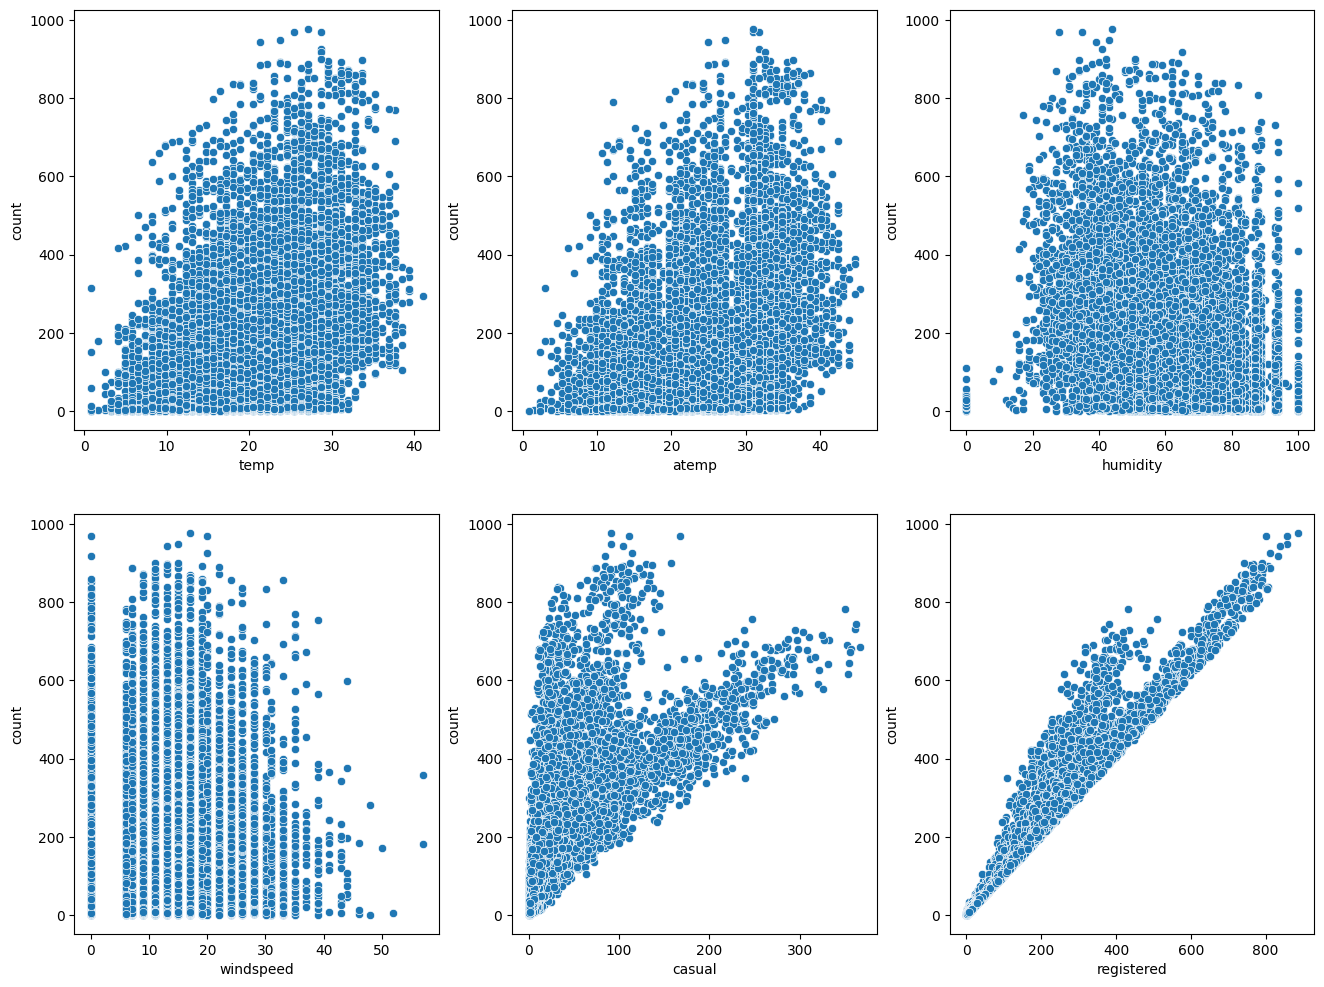

In [36]:
# Define the numerical columns
num_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered','count']

fig, axis = plt.subplots(nrows = 2,  # Setting the figure size to 2x3
                         ncols = 3,
                         figsize = (16, 12))

index = 0

for row in range(2):  # Plotting scatterplots
    for col in range(3):
        sns.scatterplot(data = df,
                        x = num_cols[index],
                        y = 'count',
                        ax = axis[row, col])
        index += 1

plt.show()  # Displaying the plots

Observation-

* Whenever the humidity is less than 20, number of bikes rented is very very low.
* Whenever the temperature is less than 10, number of bikes rented is less.
* Whenever the windspeed is greater than 35, number of bikes rented is less.

**Plotting count vs season, workingday using boxplot-**

[]

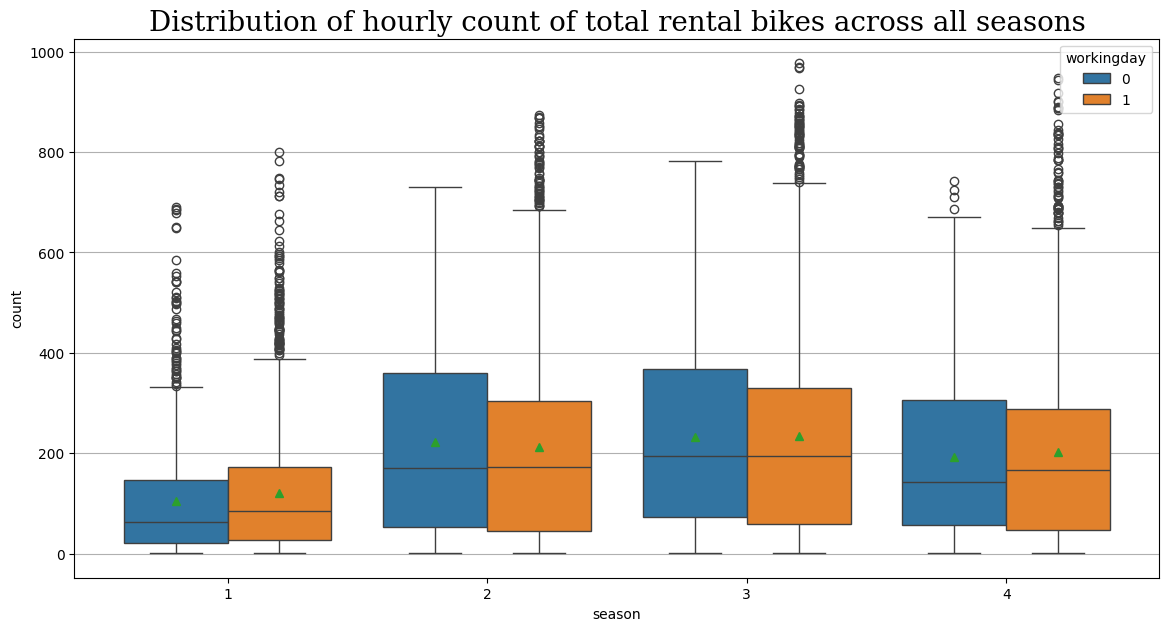

In [37]:
plt.figure(figsize = (14, 7))  # Setting the figure size to 14x7

# Setting the title of the plot
plt.title('Distribution of hourly count of total rental bikes across all seasons',
         fontdict = {'size' : 20,
                    'style' : 'normal',
                    'family' : 'serif'})

sns.boxplot(data = df,  # Plotting boxplots
            x = 'season',
            y = 'count',
            hue = 'workingday',
            showmeans = True)

plt.grid(axis = 'y', linestyle = '-')
plt.plot()  # Displaying the plots

Observation-

* The hourly count of total rental bikes is higher in the fall season, followed by the summer and winter seasons. It is generally low in the spring season.

**Plotting count vs weather, workingday using boxplot-**

[]

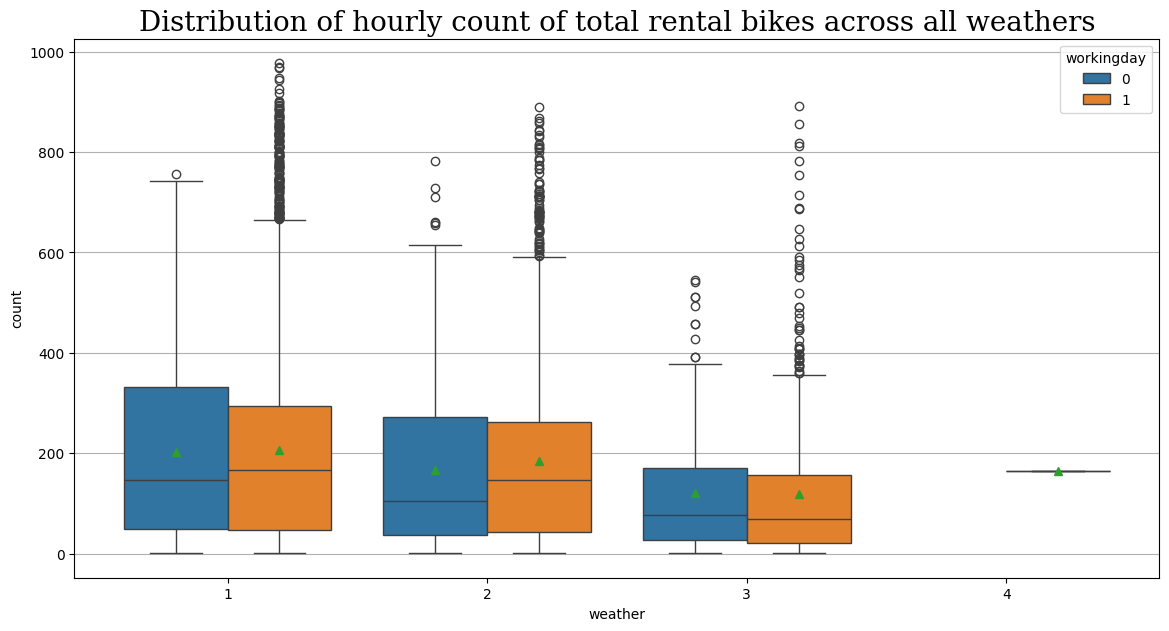

In [38]:
plt.figure(figsize = (14, 7))  # Setting the figure size to 14x7

# Setting the title of the plot
plt.title('Distribution of hourly count of total rental bikes across all weathers',
         fontdict = {'size' : 20,
                    'style' : 'normal',
                    'family' : 'serif'})

sns.boxplot(data = df,  # Plotting boxplots
            x = 'weather',
            y = 'count',
            hue = 'workingday',
            showmeans = True)

plt.grid(axis = 'y', linestyle = '-')
plt.plot()  # Displaying the plots

Observation-

* The hourly count of total rental bikes is higher in the clear and cloudy weather, followed by the misty weather and rainy weather. There are very few records for extreme weather conditions.

**Plotting jointplot of count, temperature and season-**

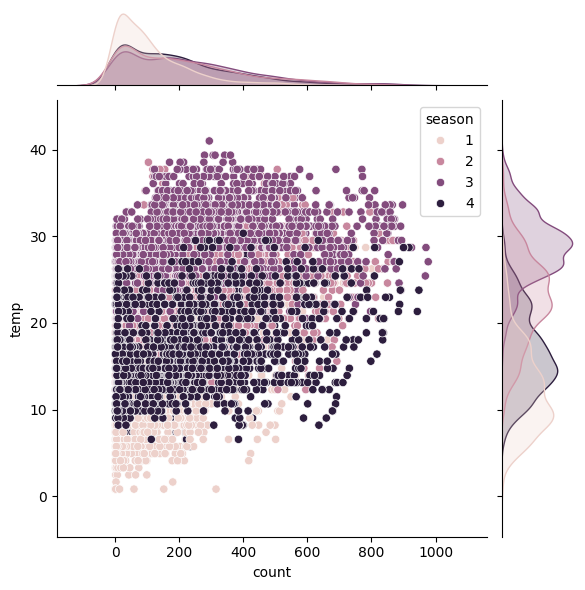

In [39]:
sns.jointplot(x = "count",  # Plotting jointplot of count, temperature and season
              y = "temp",
              data = df,
              hue = "season")

plt.show()  # Displaying the plot

**Plotting jointplot of count, temperature and workingday-**

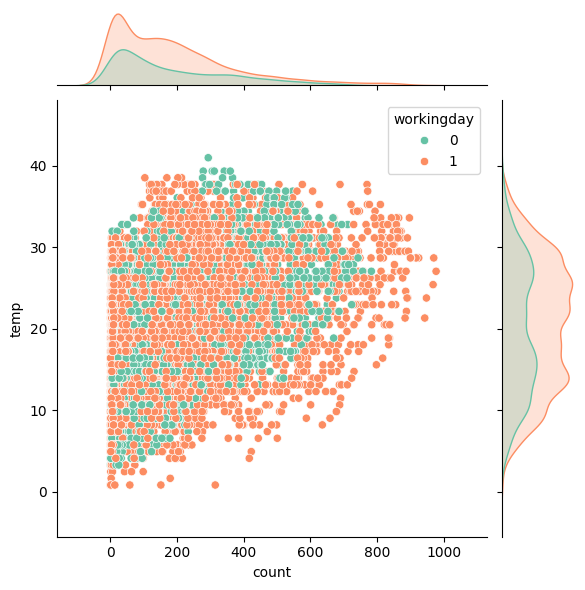

In [40]:
sns.jointplot(x = "count",  # Plotting jointplot of count, temperature and workingday
              y = "temp",
              data = df,
              hue = "workingday",
              palette = "Set2")

plt.show()  # Displaying the plot

**Plotting jointplot of count, temperature and weather-**

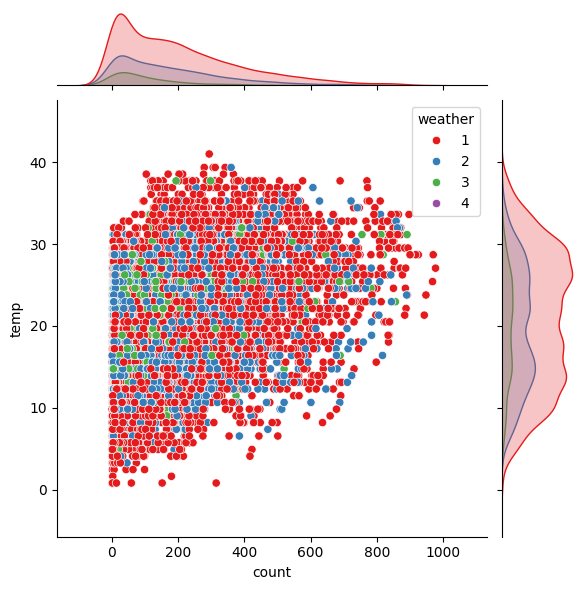

In [41]:
sns.jointplot(x = "count",  # Plotting jointplot of count, temperature and weather
              y = "temp",
              data = df,
              hue = "weather",
              palette = "Set1")

plt.show()  # Displaying the plot

Observation-

These plots gives us relationship of bike usage count vs temperature, season, workingday and weather variables

# Check for Outliers and deal with them accordingly:

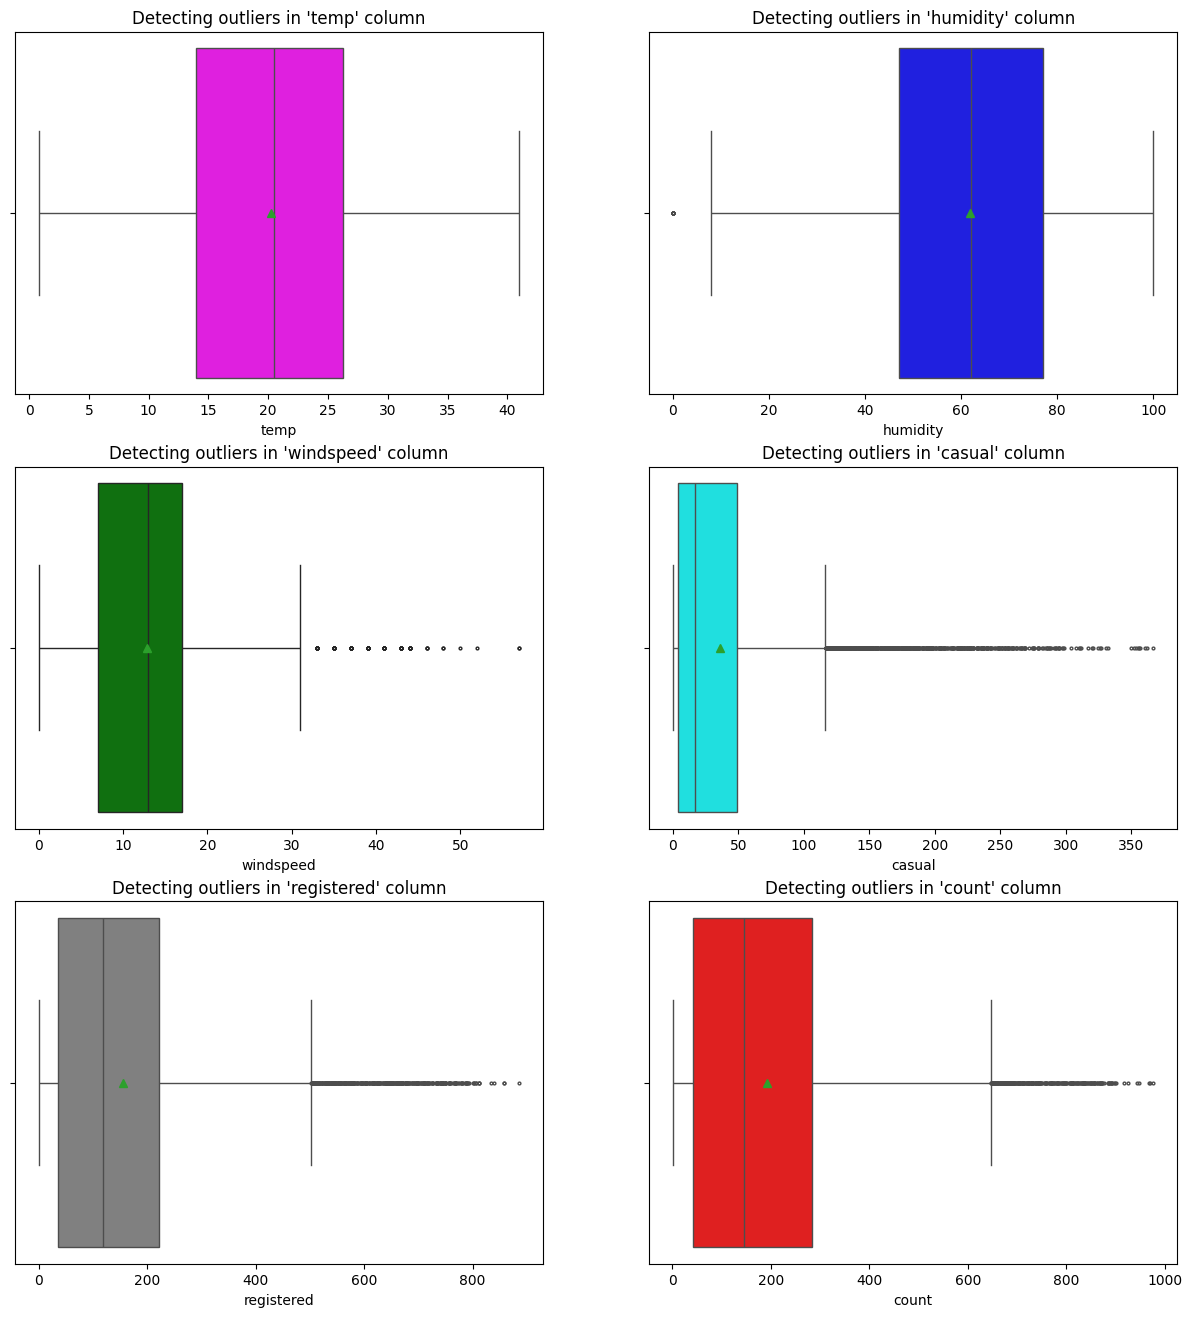

In [42]:
columns = ['temp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
colors = np.random.permutation(['red', 'blue', 'green', 'magenta', 'cyan', 'gray'])
count = 1


plt.figure(figsize = (15, 16))  # Setting the figure size to 15x16

for i in columns:
    plt.subplot(3, 2, count)
    plt.title(f"Detecting outliers in '{i}' column")
    sns.boxplot(data = df,  # Plotting boxplots
                x = df[i],
                color = colors[count - 1],
                showmeans = True,
                fliersize = 2)

    plt.plot()  # Displaying the plot
    count += 1

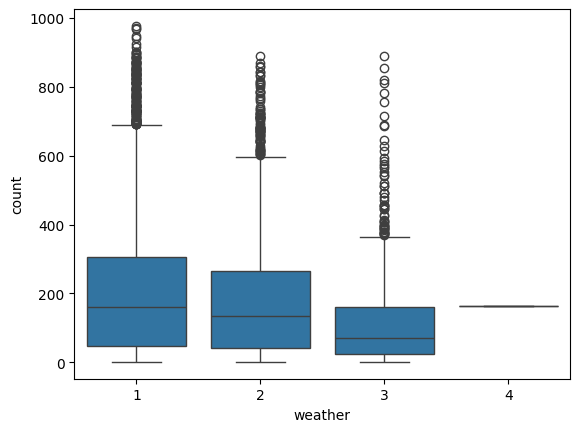

In [43]:
sns.boxplot(x = 'weather',  # Plotting the boxplot of weather and count
            y = 'count',
            data = df)

plt.show()  # Displaying the plot

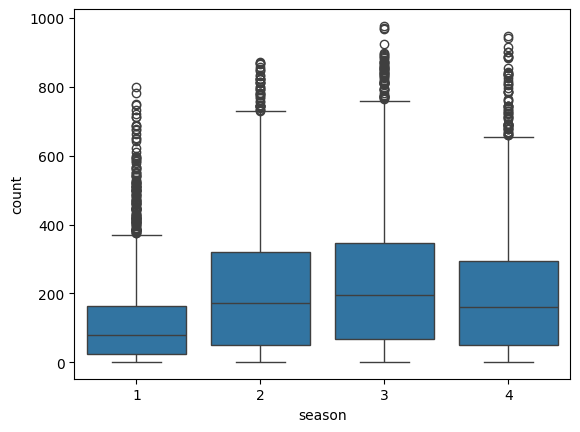

In [44]:
sns.boxplot(x = 'season',  # Plotting the boxplot of season and count
            y = 'count',
            data = df)

plt.show()  # Displaying the plot

Observation-

* There is no outlier in the temp column.
* There are few outliers present in humidity column.
* There are many outliers present in each of the columns : windspeed, casual, registered, count.
* count has outlier but we will retain because we want to do analysis on complete data.
* Removal of outlier may be cause the data loss that's why we are retaining it
* Each season has outliers we are retaing this in order to avoid the data loss.

### Establish a Relationship between Dependent and Independent Variables:

In [45]:
corr_data = df.corr()
corr_data

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
datetime,1.000000,0.480021,0.010988,-0.003658,-0.005048,0.180986,0.181823,0.032856,-0.086888,0.172728,0.314879,0.310187
season,0.480021,1.000000,0.029368,-0.008126,0.008879,0.258689,0.264744,0.190610,-0.147121,0.096758,0.164011,0.163439
holiday,0.010988,0.029368,1.000000,-0.250491,-0.007074,0.000295,-0.005215,0.001929,0.008409,0.043799,-0.020956,-0.005393
workingday,-0.003658,-0.008126,-0.250491,1.000000,0.033772,0.029966,0.024660,-0.010880,0.013373,-0.319111,0.119460,0.011594
weather,-0.005048,0.008879,-0.007074,0.033772,1.000000,-0.055035,-0.055376,0.406244,0.007261,-0.135918,-0.109340,-0.128655
temp,0.180986,0.258689,0.000295,0.029966,-0.055035,1.000000,0.984948,-0.064949,-0.017852,0.467097,0.318571,0.394454
atemp,0.181823,0.264744,-0.005215,0.024660,-0.055376,0.984948,1.000000,-0.043536,-0.057473,0.462067,0.314635,0.389784
humidity,0.032856,0.190610,0.001929,-0.010880,0.406244,-0.064949,-0.043536,1.000000,-0.318607,-0.348187,-0.265458,-0.317371
windspeed,-0.086888,-0.147121,0.008409,0.013373,0.007261,-0.017852,-0.057473,-0.318607,1.000000,0.092276,0.091052,0.101369
casual,0.172728,0.096758,0.043799,-0.319111,-0.135918,0.467097,0.462067,-0.348187,0.092276,1.000000,0.497250,0.690414


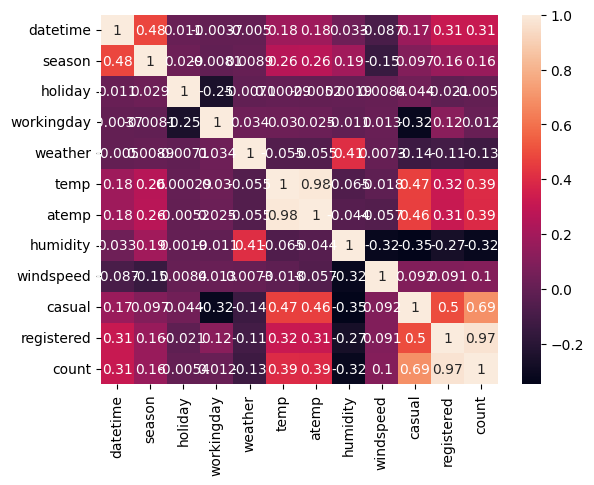

In [46]:
sns.heatmap(df.corr(),  # Plotting a correlation matrix
            annot = True)

plt.show()  # Displaying the plot

### Observation-

* Here, count column seems to have positive correlation with atemp and and negative with humidity. Although they around only 30-40%. But we can see people go out with bike more when the temp is high and humidity is low. Seems expected.
* Very High Correlation (> 0.9) exists between columns [atemp, temp] and [count, registered]
* High positively / negatively correlation (0.7 - 0.9) does not exist between any columns.
* Moderate positive correlation (0.5 - 0.7) exists between columns [casual, count], [casual, registered].
* Low Positive correlation (0.3 - 0.5) exists between columns [count, temp], [count, atemp], [casual, atemp]
* Negligible correlation exists between all other combinations of columns.

## **2. Hypothesis Testing:**
Q1- Is any significant effect of Working Day on the number of bike rides?

In [47]:
df.groupby(by = 'workingday')['count'].describe()

,count,mean,std,min,25%,50%,75%,max
workingday,,,,,,,,
0,3474.0,188.506621,173.724015,1.0,44.0,128.0,304.0,783.0
1,7412.0,193.011873,184.513659,1.0,41.0,151.0,277.0,977.0


[]

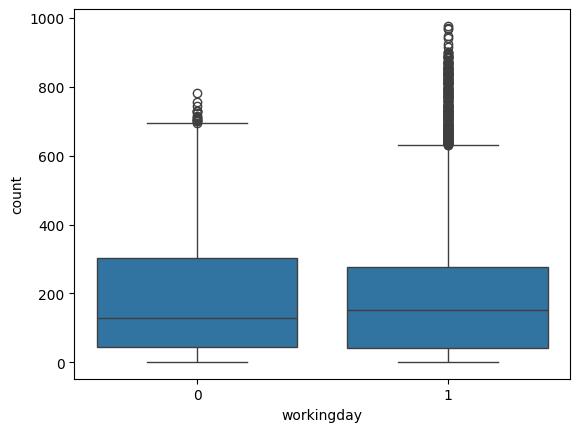

In [55]:
sns.boxplot(data = df,  # Plotting the boxplot for workingday
            x = 'workingday',
            y = 'count')

plt.plot()  # Displaying the plot

**STEP-1 :** Set up Null Hypothesis

Null Hypothesis ( H0 ) - Working Day does not have any effect on the number of electric cycles rented.

Alternate Hypothesis ( HA ) - Working Day has some effect on the number of electric cycles rented

**STEP-2 :** Checking for basic assumpitons for the hypothesis

Distribution check using QQ Plot
Homogeneity of Variances using Levene's test

**STEP-3:** Define Test statistics; Distribution of T under H0.

If the assumptions of T Test are met then we can proceed performing T Test for independent samples else we will perform the non parametric test equivalent to T Test for independent sample i.e., Mann-Whitney U rank test for two independent samples.

**STEP-4:** Compute the p-value and fix value of alpha.

We set our alpha to be 0.05

**STEP-5:** Compare p-value and alpha.

Based on p-value, we will accept or reject H0.

* p-val > alpha : Accept H0
* p-val < alpha : Reject H0

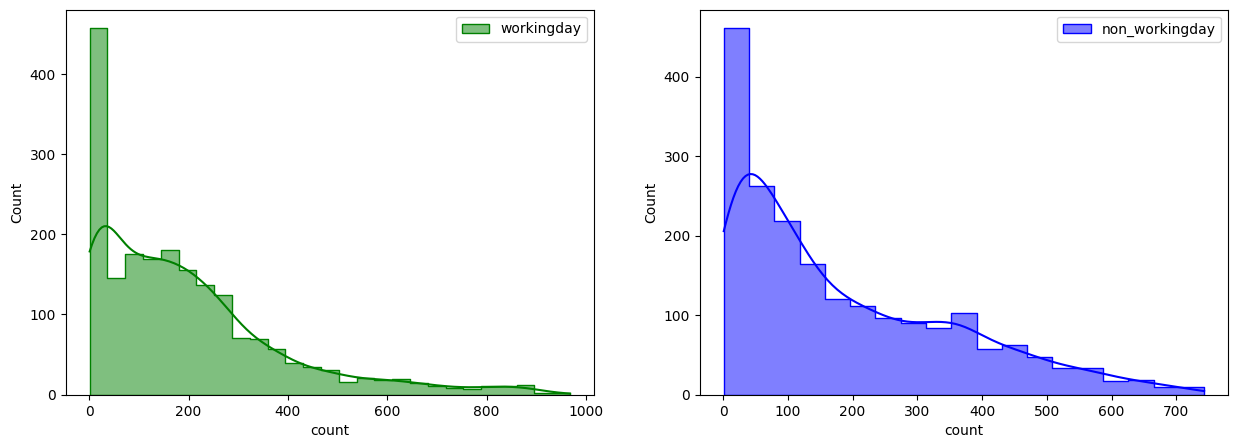

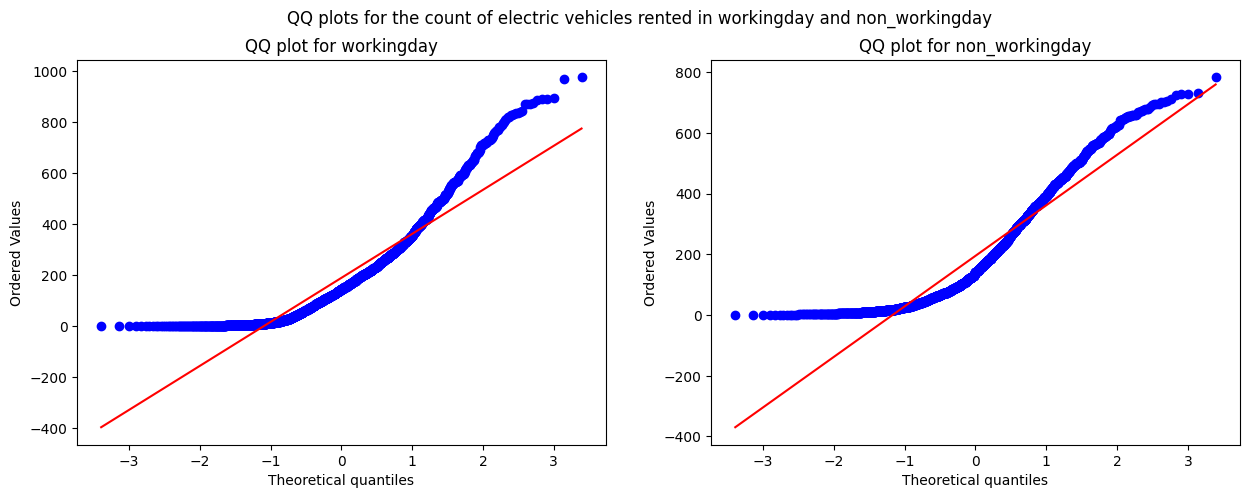

In [56]:
plt.figure(figsize = (15, 5))  # Plotting the matrix 15x5

plt.subplot(1, 2, 1)
sns.histplot(df.loc[df['workingday'] == 1, 'count'].sample(2000),  # Histogram for working days
             element = 'step',
             color = 'green',
             kde = True,
             label = 'workingday')
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(df.loc[df['workingday'] == 0, 'count'].sample(2000),  # Histogram for non-working days
             element = 'step',
             color = 'blue',
             kde = True,
             label = 'non_workingday')
plt.legend()
plt.show()  # Displaying the plot

# QQ Plots
plt.figure(figsize = (15, 5))
plt.suptitle('QQ plots for the count of electric vehicles rented in workingday and non_workingday')

plt.subplot(1, 2, 1)
spy.probplot(df.loc[df['workingday'] == 1, 'count'].sample(2000),  # QQ plot for working days
             plot = plt,
             dist = 'norm')
plt.title('QQ plot for workingday')

plt.subplot(1, 2, 2)
spy.probplot(df.loc[df['workingday'] == 0, 'count'].sample(2000),  # QQ plot for non-working days
             plot = plt,
             dist = 'norm')
plt.title('QQ plot for non_workingday')

plt.show()  # Displaying the plot

Observation-
It can be inferred from the above plot that the distributions do not follow normal distribution.

Next step-
Applying Shapiro-Wilk test for normality:

* Ho: The sample follows normal distribution
* Ha: The sample does not follow normal distribution
* alpha = 0.05
* Test Statistics : Shapiro-Wilk test for normality

In [57]:
# Applying Shapiro-Wilk test for normality for workingday
test_stat, p_value = spy.shapiro(df.loc[df['workingday'] == 1, 'count'].sample(2000))
print('p-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')


# Applying Shapiro-Wilk test for normality for non workingday
test_stat, p_value = spy.shapiro(df.loc[df['workingday'] == 0, 'count'].sample(2000))
print('\np-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')

p-value 6.335648735788223e-39
The sample does not follow normal distribution

p-value 2.3009792109587542e-36
The sample does not follow normal distribution


Next step-
Transforming the data using boxcox transformation and checking if the transformed data follows normal distribution.

In [59]:
transformed_workingday = spy.boxcox(df.loc[df['workingday'] == 1, 'count'])[0]
test_stat, p_value = spy.shapiro(transformed_workingday)
print('p-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')


transformed_non_workingday = spy.boxcox(df.loc[df['workingday'] == 0, 'count'])[0]
test_stat, p_value = spy.shapiro(transformed_non_workingday)
print('\np-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')

p-value 1.6064517647465272e-33
The sample does not follow normal distribution

p-value 8.140930902522902e-24
The sample does not follow normal distribution


**Observation**-

Even after applying the boxcox transformation on each of the "workingday" and "non_workingday" data, the samples do not follow normal distribution.

**Next step-**

Homogeneity of Variances using Lavene's test.

In [60]:
# Null Hypothesis(H0) - Homogenous Variance
# Alternate Hypothesis(HA) - Non Homogenous Variance

test_stat, p_value = spy.levene(df.loc[df['workingday'] == 1, 'count'].sample(2000),
                                df.loc[df['workingday'] == 0, 'count'].sample(2000))
print('p-value', p_value)
if p_value < 0.05:
    print('The samples do not have  Homogenous Variance')
else:
    print('The samples have Homogenous Variance ')

p-value 0.9991016685692592
The samples have Homogenous Variance 


Next step-

Since the samples are not normally distributed, T-Test cannot be applied here, we can perform its non parametric equivalent test i.e., Mann-Whitney U rank test for two independent samples:

In [61]:
test_stat, p_value = spy.mannwhitneyu(df.loc[df['workingday'] == 1, 'count'],
                                      df.loc[df['workingday'] == 0, 'count'])
print('P-value :',p_value)
if p_value < 0.05:
    print('Reject H0')
else:
    print('Fail to reject the H0')
    print("\nNo difference between workingday and overall bikes cycles mean.")
    print("So there is no significant difference of rented bikes between workingdays and not workingdays.")

P-value : 0.9679139953914079
Fail to reject the H0

No difference between workingday and overall bikes cycles mean.
So there is no significant difference of rented bikes between workingdays and not workingdays.


Observation-
Therefore, there is no significant difference of rented bikes between workingdays and not workingdays. In other words, there is no significant difference between the number of bike rides on Weekdays and Weekends.

### **Q2- Is the demand of bikes on rent the same for different Weather conditions?**

In [62]:
df.groupby(by = 'weather')['count'].describe()

,count,mean,std,min,25%,50%,75%,max
weather,,,,,,,,
1,7192.0,205.236791,187.959566,1.0,48.0,161.0,305.0,977.0
2,2834.0,178.955540,168.366413,1.0,41.0,134.0,264.0,890.0
3,859.0,118.846333,138.581297,1.0,23.0,71.0,161.0,891.0
4,1.0,164.000000,NaN,164.0,164.0,164.0,164.0,164.0


[]

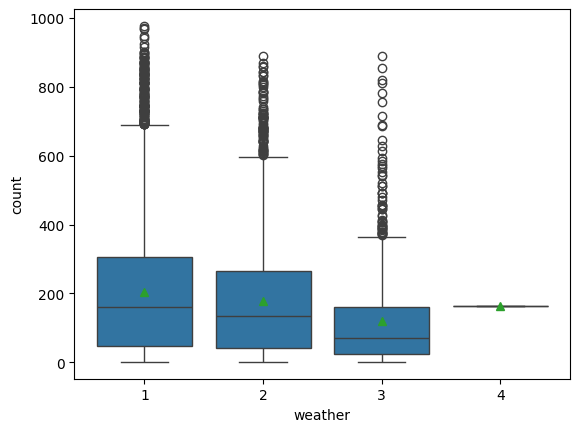

In [63]:
sns.boxplot(data = df,  # Plotting the boxplot for weather
            x = 'weather',
            y = 'count',
            showmeans = True)

plt.plot()  # Displaying the plot


In [64]:
df_weather1 = df.loc[df['weather'] == 1]
df_weather2 = df.loc[df['weather'] == 2]
df_weather3 = df.loc[df['weather'] == 3]
df_weather4 = df.loc[df['weather'] == 4]

len(df_weather1), len(df_weather2), len(df_weather3), len(df_weather4)

(7192, 2834, 859, 1)

**STEP-1 : Set up Null Hypothesis**

Null Hypothesis ( H0 ) - Mean of cycle rented per hour is same for weather 1, 2 and 3. (We wont be considering weather 4 as there in only 1 data point for weather 4 and we cannot perform a ANOVA test with a single data point for a group)

Alternate Hypothesis ( HA ) -Mean of cycle rented per hour is not same for season 1,2,3 and 4 are different.

**STEP-2 : Checking for basic assumpitons for the hypothesis**

Normality check using QQ Plot. If the distribution is not normal, use BOX-COX transform to transform it to normal distribution.

Homogeneity of Variances using Levene's test

Each observations are independent.

**STEP-3: Define Test statistics**

The test statistic for a One-Way ANOVA is denoted as F. For an independent variable with k groups, the F statistic evaluates whether the group means are significantly different.

F = MSB / MSW

Under H0, the test statistic should follow F-Distribution.

**STEP-4: Decide the kind of test.**

We will be performing right tailed f-test

**STEP-5: Compute the p-value and fix value of alpha.**

We will be computing the anova-test p-value using the f_oneway function using scipy.stats. We set our alpha to be 0.05

**STEP-6: Compare p-value and alpha.**

Based on p-value, we will accept or reject H0.
p-val > alpha : Accept H0
p-val < alpha : Reject H0

[]

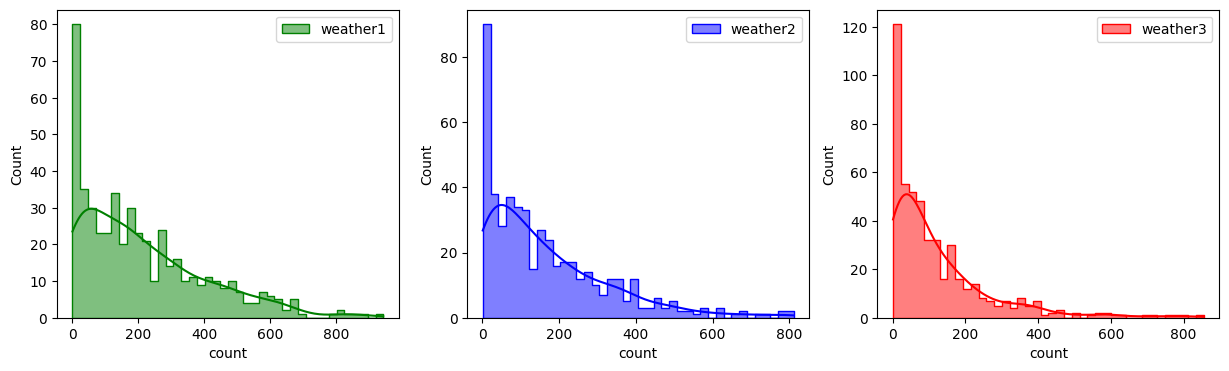

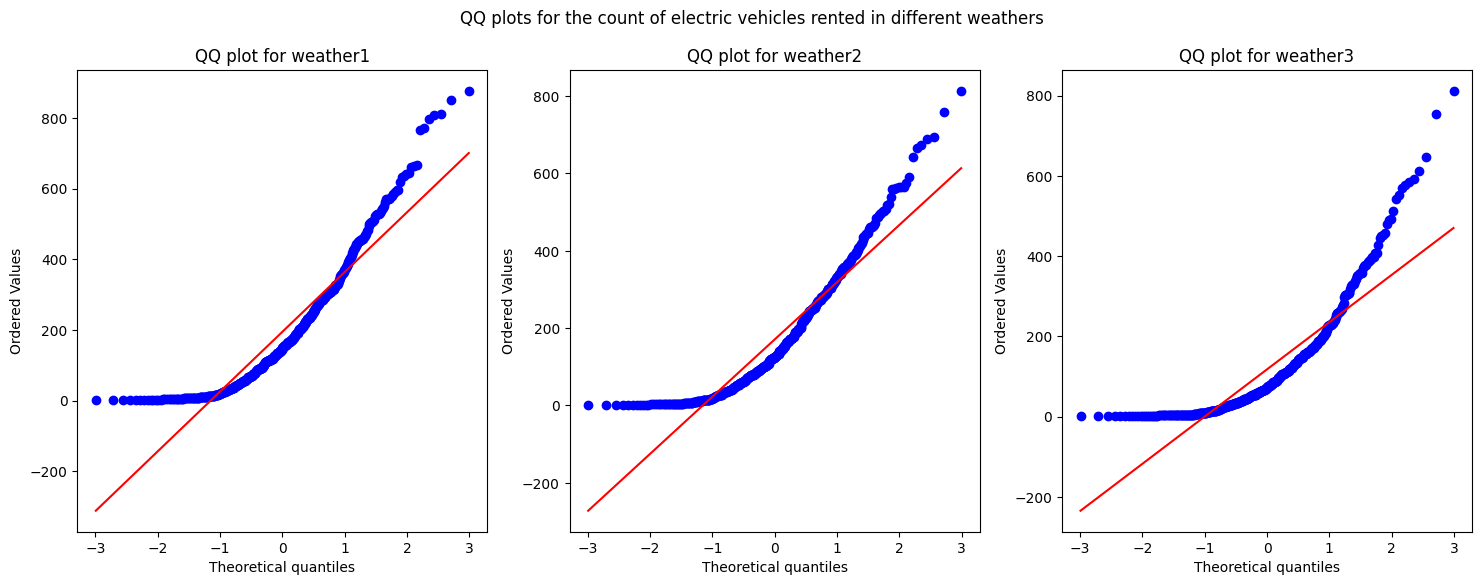

In [65]:
plt.figure(figsize = (15, 4))  # Plotting the matrix 15x4

plt.subplot(1, 3, 1)
sns.histplot(df_weather1.loc[:, 'count'].sample(500), bins = 40,  # Histogram for weather1
             element = 'step', color = 'green', kde = True, label = 'weather1')
plt.legend()

plt.subplot(1, 3, 2)
sns.histplot(df_weather2.loc[:, 'count'].sample(500), bins = 40,  # Histogram for weather2
             element = 'step', color = 'blue', kde = True, label = 'weather2')
plt.legend()

plt.subplot(1, 3, 3)
sns.histplot(df_weather3.loc[:, 'count'].sample(500), bins = 40,  # Histogram for weather3
             element = 'step', color = 'red', kde = True, label = 'weather3')
plt.legend()

plt.plot()

plt.figure(figsize = (18, 6))  # Plotting the matrix 18x6

plt.subplot(1, 3, 1)
plt.suptitle('QQ plots for the count of electric vehicles rented in different weathers')
spy.probplot(df_weather1.loc[:, 'count'].sample(500),  # QQ plot for weather1
             plot = plt,
             dist = 'norm')
plt.title('QQ plot for weather1')

plt.subplot(1, 3, 2)
spy.probplot(df_weather2.loc[:, 'count'].sample(500),  # QQ plot for weather2
             plot = plt,
             dist = 'norm')
plt.title('QQ plot for weather2')

plt.subplot(1, 3, 3)
spy.probplot(df_weather3.loc[:, 'count'].sample(500),  # QQ plot for weather3
             plot = plt,
             dist = 'norm')
plt.title('QQ plot for weather3')

plt.plot()  # Displaying the plot

Observation-
It can be inferred from the above plot that the distributions do not follow normal distribution.

### Next step-Applying Shapiro-Wilk test for normality
* Ho:The sample follows normal distribution
* Ha:The sample does not follow normal distribution
* alpha = 0.05
* Test Statistics : Shapiro-Wilk test for normality

In [66]:
# Applying Shapiro-Wilk test for normality for weather1
test_stat, p_value = spy.shapiro(df_weather1.loc[:, 'count'].sample(500))
print('p-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')


# Applying Shapiro-Wilk test for normality for weather2
test_stat, p_value = spy.shapiro(df_weather2.loc[:, 'count'].sample(500))
print('\np-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')


# Applying Shapiro-Wilk test for normality for weather3
test_stat, p_value = spy.shapiro(df_weather3.loc[:, 'count'].sample(500))
print('\np-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')

p-value 3.3973644785715897e-18
The sample does not follow normal distribution

p-value 3.6664317350622846e-19
The sample does not follow normal distribution

p-value 1.2515961132600962e-25
The sample does not follow normal distribution


Observation-
Even after applying the boxcox transformation on each of the weather data, the samples do not follow normal distribution.

Next step-
Homogeneity of Variances using Levene's test.

In [67]:
# Null Hypothesis(H0) - Homogenous Variance
# Alternate Hypothesis(HA) - Non Homogenous Variance

test_stat, p_value = spy.levene(df_weather1.loc[:, 'count'].sample(500),
                                df_weather2.loc[:, 'count'].sample(500),
                                df_weather3.loc[:, 'count'].sample(500))
print('p-value', p_value)
if p_value < 0.05:
    print('The samples do not have Homogenous Variance')
else:
    print('The samples have Homogenous Variance ')

p-value 4.440236926056462e-11
The samples do not have Homogenous Variance


Next step-
Since the samples are not normally distributed and do not have the same variance, f_oneway test cannot be performed here, we can perform its non parametric equivalent test i.e., Kruskal-Wallis H-test for independent samples.

In [68]:
alpha = 0.05
test_stat, p_value = spy.kruskal(df_weather1, df_weather2, df_weather3)
print('Test Statistic =', test_stat)
print('\np value =', p_value)

Test Statistic = [1.36471292e+01 1.83091584e+00 5.37649760e+00 1.56915686e+01
 1.08840000e+04 3.70017441e+01 4.14298489e+01 1.83168690e+03
 2.80380482e+01 2.84639685e+02 1.73745440e+02 2.04955668e+02]

p value = [1.08783632e-03 4.00333264e-01 6.79999165e-02 3.91398508e-04
 0.00000000e+00 9.22939752e-09 1.00837627e-09 0.00000000e+00
 8.15859150e-07 1.55338046e-62 1.86920588e-38 3.12206618e-45]


Next step-
Comparing p value with significance level.


In [69]:
if np.all(p_value) < alpha:
    print('Reject Null Hypothesis')
else:
    print('Failed to reject Null Hypothesis')

Reject Null Hypothesis


Q3- Is any significant effect of Holiday on the number of bike rides?

In [70]:
df.groupby(by = 'holiday')['count'].describe()

,count,mean,std,min,25%,50%,75%,max
holiday,,,,,,,,
0,10575.0,191.741655,181.513131,1.0,43.0,145.0,283.0,977.0
1,311.0,185.877814,168.300531,1.0,38.5,133.0,308.0,712.0


[]

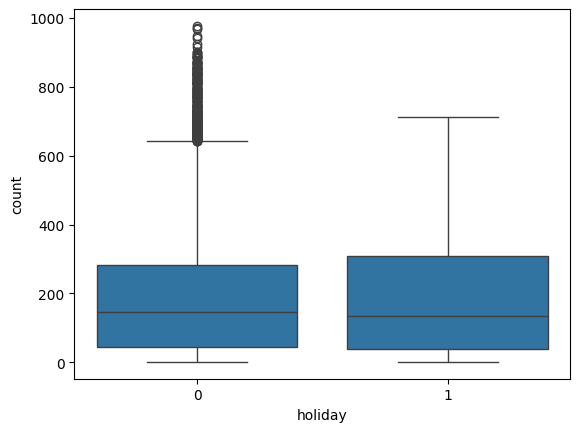

In [71]:
sns.boxplot(data = df,  # Plotting the boxplot for holiday
            x = 'holiday',
            y = 'count')

plt.plot()  # Displaying the plot

STEP-1 : Set up Null Hypothesis

* Null Hypothesis ( H0 ) - Holidays have no effect on the number of electric vehicles rented
* Alternate Hypothesis ( HA ) - Holidays has some effect on the number of electric vehicles rented

STEP-2 : Checking for basic assumpitons for the hypothesis

* Distribution check using QQ Plot
* Homogeneity of Variances using Levene's test

STEP-3: Define Test statistics; Distribution of T under H0.

* If the assumptions of T Test are met then we can proceed performing T Test for independent samples else we will perform the non parametric test equivalent to T Test for independent sample i.e., Mann-Whitney U rank test for two independent samples.

STEP-4: Compute the p-value and fix value of alpha.
* We set our alpha to be 0.05

STEP-5: Compare p-value and alpha.

Based on p-value, we will accept or reject H0.
* p-val > alpha : Accept H0
* p-val < alpha : Reject H0

[]

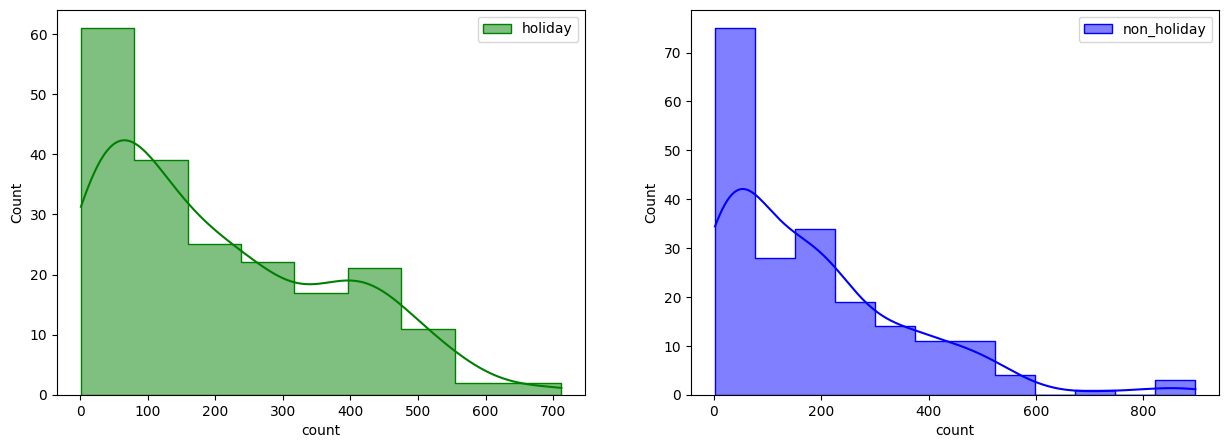

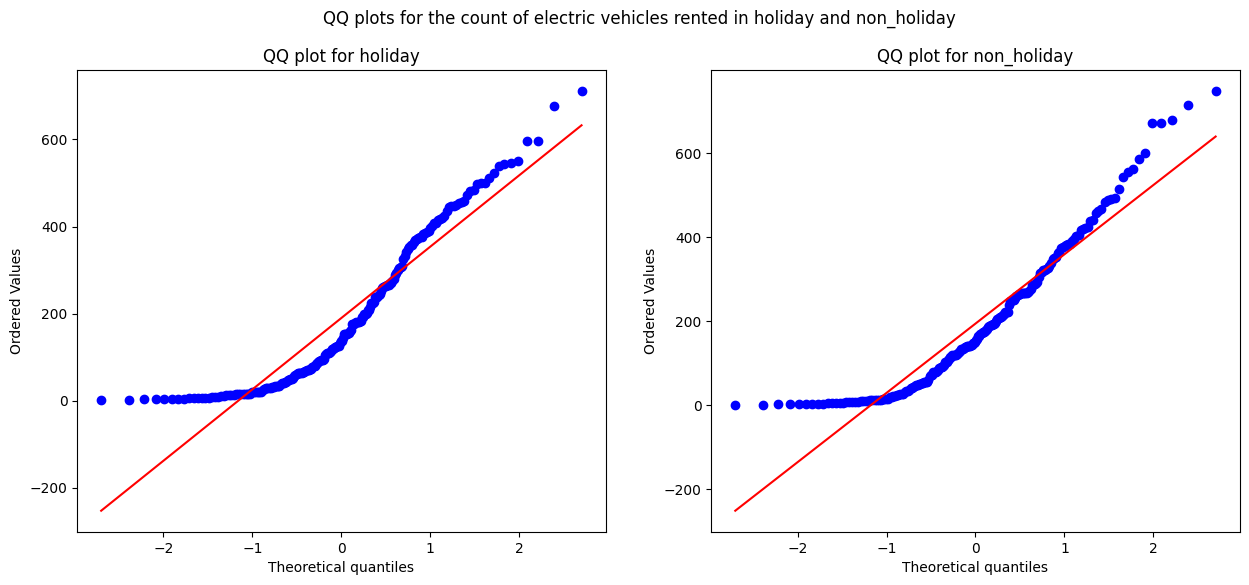

In [72]:
plt.figure(figsize = (15, 5))  # Plotting the matrix 15x10

plt.subplot(1, 2, 1)  # Plotting the histogram for holiday
sns.histplot(df.loc[df['holiday'] == 1, 'count'].sample(200),
             element = 'step',
             color = 'green',
             kde = True,
             label = 'holiday')
plt.legend()

plt.subplot(1, 2, 2)  # Plotting the histogram for non holiday
sns.histplot(df.loc[df['holiday'] == 0, 'count'].sample(200),
             element = 'step',
             color = 'blue',
             kde = True,
             label = 'non_holiday')
plt.legend()

plt.plot()  # Displying the plot

plt.figure(figsize = (15, 6))

plt.subplot(1, 2, 1)  # Plotting the QQ plot for holiday
plt.suptitle('QQ plots for the count of electric vehicles rented in holiday and non_holiday')
spy.probplot(df.loc[df['holiday'] == 1, 'count'].sample(200),
             plot = plt,
             dist = 'norm')
plt.title('QQ plot for holiday')

plt.subplot(1, 2, 2)  # Plotting the QQ plot for non holiday
spy.probplot(df.loc[df['holiday'] == 0, 'count'].sample(200),
             plot = plt,
             dist = 'norm')
plt.title('QQ plot for non_holiday')

plt.plot()  # Displying the plot

Observation-
It can be inferred from the above plot that the distributions do not follow normal distribution.

Next step-
Applying Shapiro-Wilk test for normality.

* Ho: The sample follows normal distribution
* Ha: The sample does not follow normal distribution
* alpha = 0.05
* Test Statistics : Shapiro-Wilk test for normality

In [73]:
# Applying Shapiro-Wilk test for normality for holiday
test_stat, p_value = spy.shapiro(df.loc[df['holiday'] == 1, 'count'].sample(200))
print('p-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')


# Applying Shapiro-Wilk test for normality for non holiday
test_stat, p_value = spy.shapiro(df.loc[df['holiday'] == 0, 'count'].sample(200))
print('\np-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')

p-value 1.0567948573538119e-10
The sample does not follow normal distribution

p-value 1.968966274342775e-12
The sample does not follow normal distribution


Next step-
Transforming the data using boxcox transformation and checking if the transformed data follows normal distribution.

In [74]:
transformed_holiday = spy.boxcox(df.loc[df['holiday'] == 1, 'count'])[0]
test_stat, p_value = spy.shapiro(transformed_holiday)
print('p-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')


transformed_non_holiday = spy.boxcox(df.loc[df['holiday'] == 0, 'count'].sample(5000))[0]
test_stat, p_value = spy.shapiro(transformed_non_holiday)
print('\np-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')


p-value 2.1349336320533573e-07
The sample does not follow normal distribution

p-value 9.224281801135166e-26
The sample does not follow normal distribution


Observation-
Even after applying the boxcox transformation on each of the "holiday" and "non_holiday" data, the samples do not follow normal distribution.

Next step-
Homogeneity of Variances using Levene's test.

In [75]:
test_stat, p_value = spy.levene(df.loc[df['holiday'] == 0, 'count'].sample(200),
                                df.loc[df['holiday'] == 1, 'count'].sample(200))
print('p-value', p_value)
if p_value < 0.05:
    print('\nThe samples do not have  Homogenous Variance')
else:
    print('\nThe samples have Homogenous Variance ')

p-value 0.968382196931309

The samples have Homogenous Variance 


Next step-
Since the samples are not normally distributed, T-Test cannot be applied here, we can perform its non parametric equivalent test i.e., Mann-Whitney U rank test for two independent samples.

In [76]:
test_stat, p_value = spy.mannwhitneyu(df.loc[df['holiday'] == 0, 'count'].sample(200),
                                      df.loc[df['holiday'] == 1, 'count'].sample(200))
print('P-value :',p_value)
if p_value < 0.05:
    print('\nNo.of electric cycles rented is not similar for holidays and non-holidays days')
else:
    print('\nNo.of electric cycles rented is similar for holidays and non-holidays')

P-value : 0.8402799508791261

No.of electric cycles rented is similar for holidays and non-holidays


Observation-
Therefore, the number of rental bikes is statistically similar for both holidays and non - holidays.

Q4-Is the number of bikes rented is similar or different in different season?

In [77]:
df.groupby(by = 'season')['count'].describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
1,2686.0,116.343261,125.273974,1.0,24.0,78.0,164.0,801.0
2,2733.0,215.251372,192.007843,1.0,49.0,172.0,321.0,873.0
3,2733.0,234.417124,197.151001,1.0,68.0,195.0,347.0,977.0
4,2734.0,198.988296,177.622409,1.0,51.0,161.0,294.0,948.0


In [78]:
df_season_spring = df.loc[df['season'] == 1, 'count']
df_season_summer = df.loc[df['season'] == 2, 'count']
df_season_fall = df.loc[df['season'] == 3, 'count']
df_season_winter = df.loc[df['season'] == 4, 'count']

len(df_season_spring), len(df_season_summer), len(df_season_fall), len(df_season_winter)

(2686, 2733, 2733, 2734)

[]

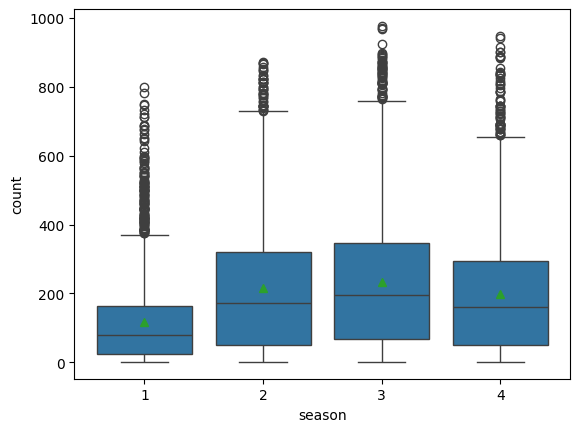

In [79]:
sns.boxplot(data = df,  # Plotting the boxplot for season
            x = 'season',
            y = 'count',
            showmeans = True)

plt.plot()  # Displaying the plot

**STEP-1 : Set up Null Hypothesis**

Null Hypothesis ( H0 ) - Mean of bike rented per hour is same for season 1,2,3 and 4.

Alternate Hypothesis ( HA ) -Mean of bike rented per hour is different for season 1,2,3 and 4.

**STEP-2 : Checking for basic assumpitons for the hypothesis**

Normality check using QQ Plot. If the distribution is not normal, use BOX-COX transform to transform it to normal distribution.
Homogeneity of Variances using Levene's test
Each observations are independent.

**STEP-3: Define Test statistics**

The test statistic for a One-Way ANOVA is denoted as F. For an independent variable with k groups, the F statistic evaluates whether the group means are significantly different.
F = MSB / MSW
Under H0, the test statistic should follow F-Distribution.

**STEP-4: Decide the kind of test.**

We will be performing right tailed f-test

**STEP-5: Compute the p-value and fix value of alpha.**

We will be computing the anova-test p-value using the f_oneway function using scipy.stats.
We set our alpha to be 0.05

**STEP-6: Compare p-value and alpha.**

Based on p-value, we will accept or reject H0.

p-val > alpha : Accept H0,
p-val < alpha : Reject H0

The one-way ANOVA compares the means between the groups you are interested in and determines whether any of those means are statistically significantly different from each other.

Specifically, it tests the null hypothesis (H0):

µ1 = µ2 = µ3 = ..... = µk

where, µ = group mean and k = number of groups.

If, however, the one-way ANOVA returns a statistically significant result, we accept the alternative hypothesis (HA), which is that there are at least two group means that are statistically significantly different from each other.

[]

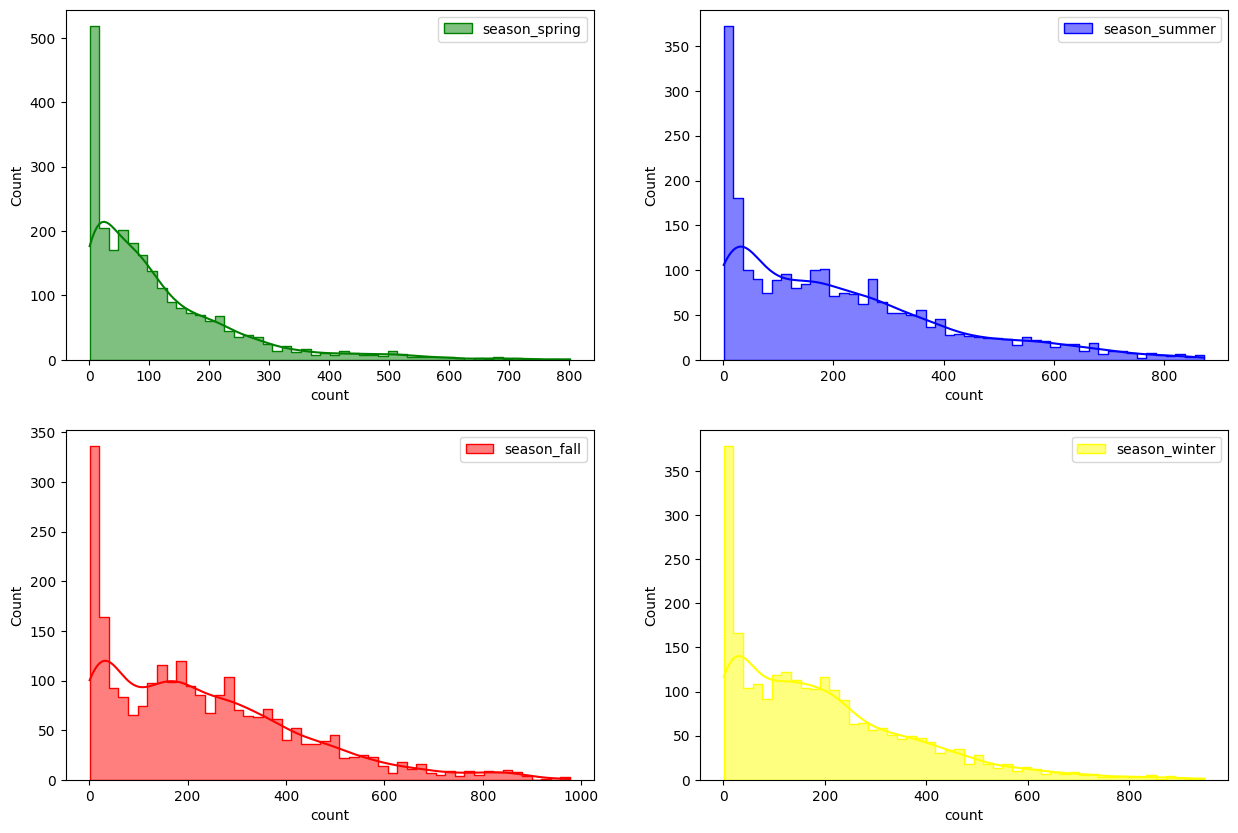

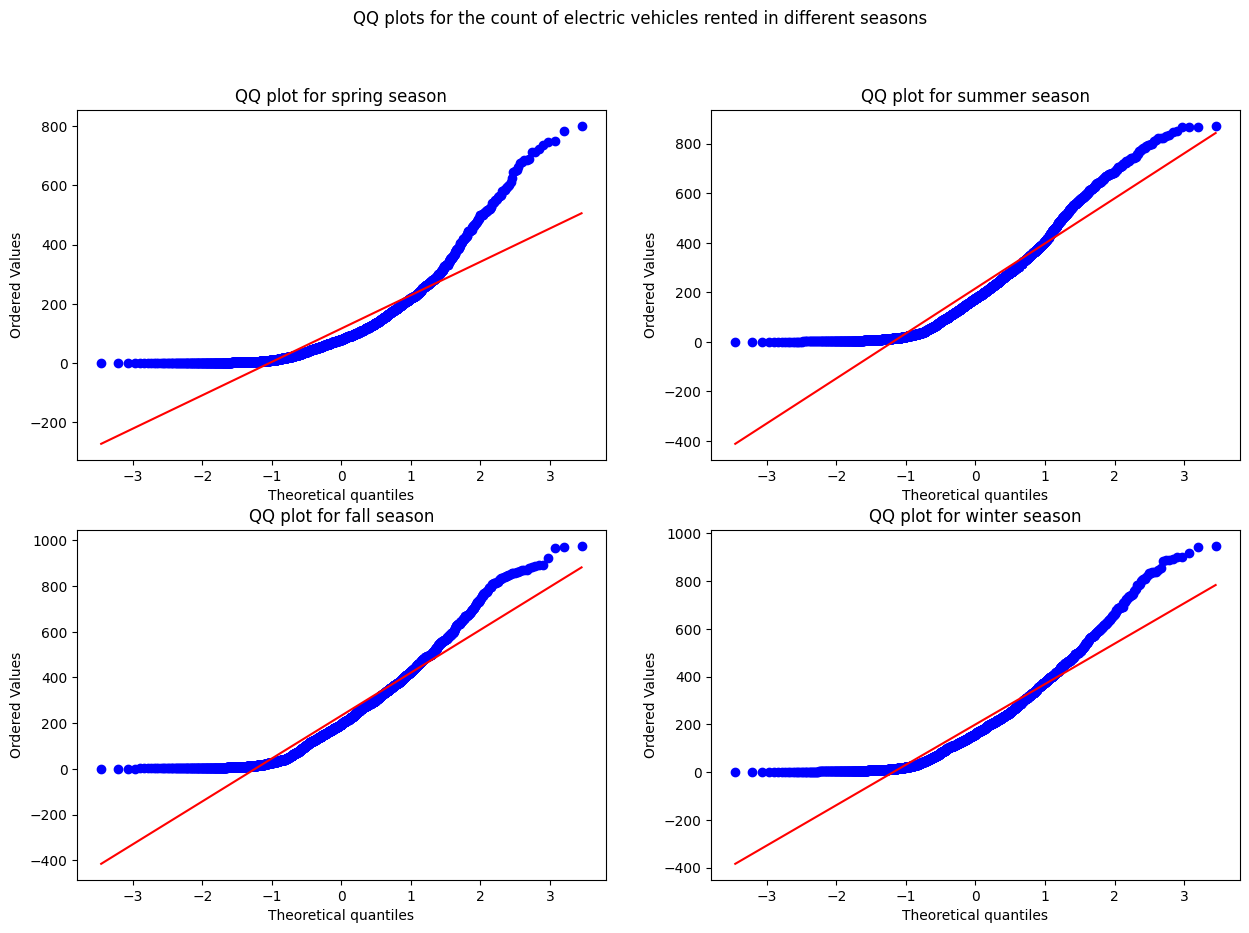

In [80]:
plt.figure(figsize = (15, 10))  # Plotting the matrix 15x10

plt.subplot(2, 2, 1)
sns.histplot(df_season_spring.sample(2500),  # Plotting the histogram for spring
             bins = 50,
             element = 'step',
             color = 'green',
             kde = True,
             label = 'season_spring')
plt.legend()

plt.subplot(2, 2, 2)
sns.histplot(df_season_summer.sample(2500),  # Plotting the histogram for summer
             bins = 50,
             element = 'step',
             color = 'blue',
             kde = True,
             label = 'season_summer')
plt.legend()

plt.subplot(2, 2, 3)
sns.histplot(df_season_fall.sample(2500),  # Plotting the histogram for fall
             bins = 50,
             element = 'step',
             color = 'red',
             kde = True,
             label = 'season_fall')
plt.legend()

plt.subplot(2, 2, 4)
sns.histplot(df_season_winter.sample(2500),  # Plotting the histogram for winter
             bins = 50,
             element = 'step',
             color = 'yellow',
             kde = True,
             label = 'season_winter')
plt.legend()

plt.plot()  # Displaying the plot



plt.figure(figsize = (15, 10))  # Plotting the matrix 15x10

plt.subplot(2, 2, 1)
plt.suptitle('QQ plots for the count of electric vehicles rented in different seasons')
spy.probplot(df_season_spring.sample(2500),  # Plotting the QQ plot for spring
             plot = plt,
             dist = 'norm')
plt.title('QQ plot for spring season')

plt.subplot(2, 2, 2)
spy.probplot(df_season_summer.sample(2500),  # Plotting the QQ plot for summer
             plot = plt,
             dist = 'norm')
plt.title('QQ plot for summer season')

plt.subplot(2, 2, 3)
spy.probplot(df_season_fall.sample(2500),  # Plotting the QQ plot for fall
             plot = plt,
             dist = 'norm')
plt.title('QQ plot for fall season')

plt.subplot(2, 2, 4)
spy.probplot(df_season_winter.sample(2500),  # Plotting the QQ plot for winter
             plot = plt,
             dist = 'norm')
plt.title('QQ plot for winter season')

plt.plot()  # Displaying the plot

Observation-
Visual Tests to know if the samples follow normal distribution.

In [81]:
# Applying Shapiro-Wilk test for normality for spring
test_stat, p_value = spy.shapiro(df_season_spring.sample(2500))
print('p-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')


# Applying Shapiro-Wilk test for normality for summer
test_stat, p_value = spy.shapiro(df_season_summer.sample(2500))
print('\np-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')


# Applying Shapiro-Wilk test for normality for fall
test_stat, p_value = spy.shapiro(df_season_fall.sample(2500))
print('\np-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')


# Applying Shapiro-Wilk test for normality for winter
test_stat, p_value = spy.shapiro(df_season_winter.sample(2500))
print('\np-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')

p-value 1.3013770506411017e-47
The sample does not follow normal distribution

p-value 6.508282308157867e-38
The sample does not follow normal distribution

p-value 6.714711133975943e-35
The sample does not follow normal distribution

p-value 3.3782494971423644e-38
The sample does not follow normal distribution


Next step-
Transforming the data using boxcox transformation and checking if the transformed data follows normal distribution.

In [82]:
transformed_df_season_spring = spy.boxcox(df_season_spring.sample(2500))[0]
test_stat, p_value = spy.shapiro(transformed_df_season_spring)
print('p-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')


transformed_df_season_summer = spy.boxcox(df_season_summer.sample(2500))[0]
test_stat, p_value = spy.shapiro(transformed_df_season_summer)
print('\np-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')


transformed_df_season_fall = spy.boxcox(df_season_fall.sample(2500))[0]
test_stat, p_value = spy.shapiro(transformed_df_season_fall)
print('\np-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')


transformed_df_season_winter = spy.boxcox(df_season_winter.sample(2500))[0]
test_stat, p_value = spy.shapiro(transformed_df_season_winter)
print('\np-value', p_value)
if p_value < 0.05:
    print('The sample does not follow normal distribution')
else:
    print('The sample follows normal distribution')

p-value 9.406139240716742e-17
The sample does not follow normal distribution

p-value 2.5247535616175684e-21
The sample does not follow normal distribution

p-value 1.4237677835728428e-21
The sample does not follow normal distribution

p-value 2.789224063918013e-20
The sample does not follow normal distribution


Observation-
Even after applying the boxcox transformation on each of the season data, the samples do not follow normal distribution.

Next step-
Homogeneity of Variances using Levene's test.

In [83]:
test_stat, p_value = spy.levene(df_season_spring.sample(2500),
                                df_season_summer.sample(2500),
                                df_season_fall.sample(2500),
                                df_season_winter.sample(2500))
print('p-value', p_value)

if p_value < 0.05:
    print('The samples do not have  Homogenous Variance')
else:
    print('The samples have Homogenous Variance ')

p-value 1.7078655991361974e-109
The samples do not have  Homogenous Variance


Next step-
Since the samples are not normally distributed and do not have the same variance, f_oneway test cannot be performed here, we can perform its non parametric equivalent test i.e., Kruskal-Wallis H-test for independent samples.

In [84]:
alpha = 0.05

test_stat, p_value = spy.kruskal(df_season_spring, df_season_summer, df_season_fall,df_season_winter)

print('Test Statistic =', test_stat)
print('p value =', p_value)

Test Statistic = 699.6668548181988
p value = 2.479008372608633e-151


Next step-
Comparing p value with significance level.

In [85]:
if p_value < alpha:
    print('Reject Null Hypothesis')
else:
    print('Failed to reject Null Hypothesis')

Reject Null Hypothesis


Observaton-
Therefore, the average number of rental bikes is statistically different for different seasons.

### **Q5- Is weather dependent on the season?**

In [86]:
df[['weather', 'season']].describe()

,weather,season
count,10886,10886
unique,4,4
top,1,4
freq,7192,2734


**Observation-**
It is clear from the above statistical description that both 'weather' and 'season' features are categorical in nature.

STEP-1 : Set up Null Hypothesis

* Null Hypothesis ( H0 ) - Weather is independent of season
* Alternate Hypothesis ( HA ) - Weather is dependent of seasons.

STEP-2: Define Test statistics
* Since we have two categorical features, the Chi- square test is applicable here. Under H0, the test statistic should follow Chi-Square Distribution.

STEP-3: Checking for basic assumptons for the hypothesis (Non-Parametric Test)
* The data in the cells should be frequencies, or counts of cases.
* The levels (or categories) of the variables are mutually exclusive. That is, a particular subject fits into one and only one level of each of the variables.
* There are 2 variables, and both are measured as categories.
* The value of the cell expecteds should be 5 or more in at least 80% of the cells, and no cell should have an expected of less than one (3).

STEP-4: Compute the p-value and fix value of alpha.
* We will be computing the chi square-test p-value using the chi2_contingency function using scipy.stats. We set our alpha to be 0.05

STEP-5: Compare p-value and alpha.
* Based on p-value, we will accept or reject H0.
1. p-val > alpha : Accept H0
2. p-val < alpha : Reject H0

The Chi-square statistic is a non-parametric (distribution free) tool designed to analyze group differences when the dependent variable is measured at a nominal level. Like all non-parametric statistics, the Chi-square is robust with respect to the distribution of the data. Specifically, it does not require equality of variances among the study groups or homoscedasticity in the data

In [87]:
cross_table = pd.crosstab(index = df['season'],
                          columns = df['weather'],
                          values = df['count'],
                          aggfunc = np.sum).replace(np.nan, 0)

cross_table

weather,1,2,3,4
season,,,,
1,223009.0,76406.0,12919.0,164.0
2,426350.0,134177.0,27755.0,0.0
3,470116.0,139386.0,31160.0,0.0
4,356588.0,157191.0,30255.0,0.0


**Observation-**
Since the above contingency table has one column in which the count of the rented electric bike is less than 5 in most of the cells, we can remove the weather 4 and then proceed further.

In [88]:
cross_table = pd.crosstab(index = df['season'],
                          columns = df.loc[df['weather'] != 4, 'weather'],
                          values = df['count'],
                          aggfunc = np.sum).to_numpy()[:, :3]

cross_table

array([[223009,  76406,  12919],
       [426350, 134177,  27755],
       [470116, 139386,  31160],
       [356588, 157191,  30255]])

In [89]:
chi_test_stat, p_value, dof, expected = spy.chi2_contingency(observed = cross_table)

print('Test Statistic =', chi_test_stat)
print('p value =', p_value)
print('-' * 65)
print("Expected : \n", expected)

Test Statistic = 10838.372332480214
p value = 0.0
-----------------------------------------------------------------
Expected : 
 [[221081.86259035  75961.44434981  15290.69305984]
 [416408.3330293  143073.60199337  28800.06497733]
 [453484.88557396 155812.72247031  31364.39195574]
 [385087.91880639 132312.23118651  26633.8500071 ]]


Observation-
Comparing p value with significance level.

In [90]:
if p_value < alpha:
    print('Reject Null Hypothesis')
else:
    print('Failed to reject Null Hypothesis')

Reject Null Hypothesis


Observation-
Therefore, there is statistically significant dependency of weather and season based on the number of bikes rented.

# **Insights**

1. The dataset covers the period from January 1, 2011, to December 19, 2012, giving us approximately 719 days of data.
2. For every 100 bike users, around 19 are casual users, while the remaining 81 are registered users, showing that registered customers make up the majority of the user base.
3. The average hourly bike rentals increased from 144 in 2011 to 239 in 2012. This represents an impressive 65.41% year-on-year growth in hourly rental demand.
4. Bike rental demand follows a clear seasonal trend. Demand is generally higher during the spring and summer, starts declining during the fall, and reaches its lowest levels during the winter months.
5. January has the lowest average hourly bike rentals, followed by February and March, indicating relatively lower demand during the beginning of the year.
6. Rental demand varies considerably throughout the day. It is lowest during the early morning, rises sharply during the morning, reaches its peak during the afternoon, and then gradually falls through the evening and night.
7. The temperature remains below 28°C for more than 80% of the recorded hours, suggesting that extremely high temperatures are relatively uncommon in the dataset.
8. More than 80% of the observations have humidity above 40%, meaning the weather conditions are generally moderate to fairly humid for most of the recorded period.
9. Over 85% of the windspeed observations are below 20, indicating that extremely strong winds are relatively uncommon.
10. Bike rentals are highest during clear and cloudy weather, followed by misty conditions and then rainy weather. There are comparatively very few observations under extreme weather conditions.
11. The average hourly bike rental count is statistically similar on working days and non-working days, suggesting that the overall rental volume does not differ significantly based on whether it is a working day.
12. The analysis indicates a statistically significant relationship between weather conditions, seasons, and the hourly number of bikes rented.
13. The hourly number of bike rentals differs significantly across different weather conditions, confirming that weather has a meaningful impact on rental demand.
14. There is no statistically significant relationship between weather categories 1, 2, and 3 and the season when considering the average hourly bike rental count.
15. The hourly number of bike rentals differs significantly across seasons, further confirming that seasonality plays an important role in rental demand.


### **Recommendations**

* **Seasonal Marketing:** Since bike rentals show a clear seasonal trend, Yulu can align its marketing campaigns with periods of higher demand. Spring and summer can be targeted with attractive offers, seasonal discounts, and special rental packages to maximize customer acquisition and usage.

* **Time-based Pricing:** Rental demand changes significantly throughout the day, so Yulu could experiment with **time-based pricing**. Lower prices during off-peak hours could encourage customers to rent bikes when demand is lower, while peak-hour pricing can help manage high demand and optimize fleet utilization.

* **Weather-based Promotions:** Weather has a noticeable impact on rental demand, with the highest usage seen during clear and cloudy conditions. Yulu can take advantage of this by running **weather-triggered offers and promotions** when favorable riding conditions are expected.

* **User Segmentation:** With around **81% of users being registered customers**, Yulu should focus on retaining and engaging this segment through loyalty programs, exclusive offers, and personalized recommendations. For the 19% casual users, campaigns can highlight the convenience and benefits of using Yulu for occasional trips and encourage them to become regular users.

* **Optimize Inventory:** Yulu can use seasonal and monthly demand patterns to plan its fleet more efficiently. During lower-demand months such as **January, February, and March**, the company can reduce the number of bikes deployed in less busy locations. During peak seasons, additional bikes should be positioned in high-demand areas to avoid shortages.

* **Improve Weather Data Collection:** Since the dataset contains relatively few observations for extreme weather conditions, Yulu could improve its data collection for these scenarios. Better data would help the company understand how extreme weather affects demand and make more informed decisions around fleet management, safety measures, and operations.

* **Improve Customer Comfort:** Since weather conditions can influence the riding experience, Yulu could consider providing useful amenities such as **rain protection, water bottles, or other weather-related accessories** where appropriate. These small improvements could make the service more convenient and improve overall customer satisfaction.

* **Collaborate with Weather Services:** Yulu could integrate real-time weather information into its app and marketing strategy. Providing users with weather forecasts and highlighting favorable riding conditions could encourage customers to plan their rides and potentially increase bookings during suitable weather.

* **Seasonal Bike Maintenance:** Yulu should schedule **preventive maintenance before periods of high demand** to ensure that the fleet is ready when customers need it most. Regular inspections throughout the year can also reduce breakdowns, improve bike availability, and provide a better customer experience.

* **Customer Feedback and Reviews:** Yulu should actively encourage customers to share feedback about their rental experience. Regularly analyzing this feedback can help identify recurring issues, understand customer expectations, and prioritize improvements to the service.

* **Social Media Marketing:** Social media can be used to showcase real customer experiences, attractive biking routes, and the convenience of using Yulu. Customer testimonials, engaging content, contests, and targeted campaigns can help Yulu reach different user segments and increase brand awareness and bookings.

* **Special Occasion Discounts:** Since Yulu promotes sustainable and eco-friendly transportation, it can use environmentally focused occasions such as **Earth Day (April 22), World Environment Day (June 5), and World Zero Emissions Day (September 21)** to run special discounts or promotional campaigns. These initiatives can both attract new customers and reinforce Yulu's sustainability-focused brand image.
